In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import statsmodels.formula.api as smf
import matplotlib.patches as mpatches

plt.rcParams["font.size"] = 14

In [2]:
# Replace with the actual paths to your CSV files

dx_df = pd.read_csv('data/DXSUM_17Feb2026.csv')
dem  = pd.read_csv('data/PTDEMOG_17Feb2026.csv') 
adas = pd.read_csv('data/ADAS_17Feb2026.csv')
medhist = pd.read_csv('data/MEDHIST_17Feb2026.csv')
recmhist = pd.read_csv('data/RECMHIST_17Feb2026.csv')
reccmeds = pd.read_csv('data/RECCMEDS_16Mar2026.csv')
backmeds = pd.read_csv('data/BACKMEDS_16Mar2026.csv')
demographics = pd.read_csv('data/PTDEMOG_17Feb2026.csv')
apoe_df = pd.read_csv("data/APOERES_17Feb2026.csv")

apoe_df["CARRIER"] = apoe_df["GENOTYPE"].isin(["3/4","4/4"])
apoe_df["HOMO"] = apoe_df["GENOTYPE"].isin(["4/4"])


/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_89371/1416927656.py:8: DtypeWarning: Columns (8,11,13,14,17,21,22,33,34) have mixed types. Specify dtype option on import or set low_memory=False.
  reccmeds = pd.read_csv('data/RECCMEDS_16Mar2026.csv')


In [3]:
"""CSF_AD = pd.read_csv('data/CSF_AD.csv')
demo_and_comorb = pd.read_csv('data/demo_and_comorb.csv')
dx_df = pd.read_csv('data/DXSUM_17Feb2026.csv')
medhist = pd.read_csv('data/MEDHIST_17Feb2026.csv')
recmhist = pd.read_csv('data/RECMHIST_17Feb2026.csv')"""

"CSF_AD = pd.read_csv('data/CSF_AD.csv')\ndemo_and_comorb = pd.read_csv('data/demo_and_comorb.csv')\ndx_df = pd.read_csv('data/DXSUM_17Feb2026.csv')\nmedhist = pd.read_csv('data/MEDHIST_17Feb2026.csv')\nrecmhist = pd.read_csv('data/RECMHIST_17Feb2026.csv')"

### Preprocessing demographic, cognitive, APOE, and CSF data into one df:

In [4]:
def visit_to_months(v):
    if pd.isna(v):
        return np.nan
    v = v.lower()
    if v in ["bl", "sc"]:
        return 0
    if v.startswith("m"):
        return float(v[1:])  # strip the 'm'
    if v.startswith("v"):
        return float(v[1:])  # strip the 'v'
    
    return np.nan

baseline_codes = ["bl", "4_bl"]
adas["time_months"] = adas["VISCODE"].apply(visit_to_months)

baseline_dates = (
    adas[adas["VISCODE"].isin(baseline_codes)]
    .groupby("RID")["VISDATE"]
    .min()
)

adas_df = adas.merge(
    baseline_dates.rename("baseline_date"),
    on="RID",
    how="left"
)

adas_df["days_since_bl"] = (
    pd.to_datetime(adas_df["VISDATE"]) -
    pd.to_datetime(adas_df["baseline_date"])
)

# Merge ADAS scores with diagnosis data
adas_AD_dx = pd.merge(adas_df, dx_df[["RID", "VISCODE", "DIAGNOSIS"]], on=["RID", "VISCODE"], how="left")
adas_AD_dx['VISDATE'] = pd.to_datetime(adas_AD_dx['VISDATE'])


In [13]:
demographics_unique = demographics[["RID", "PTDOB", "PTGENDER", "PTEDUCAT",'PTETHCAT', 'PTRACCAT']].drop_duplicates(subset=["RID"])

# Merge ADAS test scores with demographics
AD_dem = adas_AD_dx.merge(
    demographics_unique,
    on="RID",
    how="left",
    validate="many_to_one"
)

print(f"Number of individuals with demographic data and cognitive data: {AD_dem['RID'].nunique()}")

recmhist_bl =recmhist[recmhist["VISCODE"].isin(['sc','v01'])]

AD = AD_dem.merge(
    recmhist_bl[["RID",  "MHDESC"]].drop_duplicates(subset=["RID"]),
    on=["RID"],
    how="inner",
    validate="many_to_one"
)

print(f"Number of individuals with demographic data, cognitive data and recent medical history: {AD['RID'].nunique()}")

# Add baseline age and ADAS13 score to all later visits
ad_start = AD[['RID', 'VISCODE', 'VISDATE', 'TOTAL13', 'PTGENDER', 'PTDOB', 'PTEDUCAT']].copy()
first_entries = (
    ad_start
    .sort_values('VISDATE')
    .groupby('RID')
    .first()
    .reset_index()
)
print(first_entries['VISCODE'].value_counts())
first_entries['VISDATE'] = pd.to_datetime(first_entries['VISDATE'])
first_entries['PTDOB'] = pd.to_datetime(first_entries['PTDOB'])

# Calculate age at conversion (in years)
first_entries['age_at_baseline'] = (
    (first_entries['VISDATE'] - first_entries['PTDOB'])
    .dt.days / 365.25
)

ad_start = first_entries.rename(columns={
    'VISDATE': 'Study_start_date',
    'TOTAL13': 'TOTAL13_AD_start'
})

AD_new = AD.merge(ad_start[['RID', 'Study_start_date', 'TOTAL13_AD_start', 'age_at_baseline']], on='RID', how='left')
print(AD_new["RID"].nunique())


Number of individuals with demographic data and cognitive data: 3027
Number of individuals with demographic data, cognitive data and recent medical history: 1735
VISCODE
bl     947
v03    788
Name: count, dtype: int64
1735


/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_89371/2850068431.py:35: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  first_entries['PTDOB'] = pd.to_datetime(first_entries['PTDOB'])


In [14]:
model_vars = [
    "TOTAL13",
    "TOTAL13_AD_start",
    "VISCODE",
    "VISDATE",
    "PHASE",
    "days_since_entry",
    "age_at_baseline",
    "PTGENDER",
    'PTETHCAT', 
    'PTRACCAT',
    "CARRIER",
    "HOMO",
    "PTEDUCAT",
    "RID",
]

# Merge APOE carrier status and homozygosity into the ADAS and demographics merged dataframe
AD_df = AD_new.merge(apoe_df[["RID", "CARRIER", "HOMO"]], on="RID", how="left")

AD_df['VISDATE'] = pd.to_datetime(AD_df['VISDATE'])
AD_df['Study_start_date'] = pd.to_datetime(AD_df['Study_start_date'])
AD_df['days_since_entry'] = (AD_df['VISDATE'] - AD_df['Study_start_date']).dt.days

AD_model = AD_df[model_vars].dropna() # dropna to ensure we have complete data for MLMs - this will drop individuals with missing APOE status, education, or demographics
AD_model["time_years"] = AD_model["days_since_entry"] / 365.25

print(AD_model["RID"].nunique())

1722


### Add CSF data:

In [17]:
CSF = pd.read_csv("data/UPENNBIOMK_ROCHE_ELECSYS_19Feb2026.csv")
print(CSF.columns)

CSF["PTAU_ABETA42"] = CSF["PTAU"] / CSF["ABETA42"]
#CSF["ABETA"] = CSF["ABETA40"] / CSF["ABETA42"] # Can't use due to high sparsity of ABETA40 values

CSF_bl = CSF[CSF["VISCODE2"] == "bl"]
CSF_bl["CSF_date"] = CSF_bl["EXAMDATE"]

not_na_AB = CSF_bl["ABETA42"].notna().sum()
print(f"Non-missing values for AB42: {not_na_AB}")

not_na_AB40 = CSF_bl["ABETA40"].notna().sum()
print(f"Non-missing values for AB40: {not_na_AB40}")

Index(['PHASE', 'PTID', 'RID', 'VISCODE2', 'EXAMDATE', 'BATCH', 'RUNDATE',
       'ABETA40', 'ABETA42', 'TAU', 'PTAU', 'COMMENT', 'update_stamp'],
      dtype='object')
Non-missing values for AB42: 1619
Non-missing values for AB40: 468


/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_89371/1653926308.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CSF_bl["CSF_date"] = CSF_bl["EXAMDATE"]


In [18]:
CSF_AD = AD_model.merge(
    CSF_bl[["RID", "VISCODE2", "PTAU", "ABETA42", "PTAU_ABETA42", "CSF_date"]],
    on=["RID"],
    how="left")

CSF_AD["time_sq"] = CSF_AD["time_years"] ** 2

CSF_AD = CSF_AD.dropna(subset=["TOTAL13"])
CSF_AD = CSF_AD.dropna(subset=["PTAU_ABETA42"])
CSF_AD = CSF_AD.dropna(subset=["PTAU"])
CSF_AD = CSF_AD.dropna(subset=["ABETA42"])

print(CSF_AD["RID"].nunique())

1214


In [19]:
# Check merges did not result in duplicate rows
print(CSF_AD.groupby(['RID', 'VISCODE']).size().sort_values(ascending=False).head()) # should all be 1s, if there are any >1 then we have duplicate rows for some individuals and need to investigate further

RID   VISCODE
3     bl         1
4399  v41        1
4401  y4         1
      y2         1
      v41        1
dtype: int64


In [20]:
# Save the final dataset 
CSF_AD.to_csv('data/CSF_AD.csv', index=False)

### Load preprocessed df and define models:

In [21]:
CSF_AD = pd.read_csv('data/CSF_AD.csv')

In [22]:
print(CSF_AD.columns)

Index(['TOTAL13', 'TOTAL13_AD_start', 'VISCODE', 'VISDATE', 'PHASE',
       'days_since_entry', 'age_at_baseline', 'PTGENDER', 'PTETHCAT',
       'PTRACCAT', 'CARRIER', 'HOMO', 'PTEDUCAT', 'RID', 'time_years',
       'VISCODE2', 'PTAU', 'ABETA42', 'PTAU_ABETA42', 'CSF_date', 'time_sq'],
      dtype='object')


In [23]:
def pretty_label(var_name):
    """
    Converts snake_case variable names into publication-ready labels.
    """

    # Remove common prefixes
    prefixes = ["adas_", "cdr_", "mmse_"]
    for p in prefixes:
        if var_name.startswith(p):
            var_name = var_name[len(p):]
   
    # Replace underscores with spaces
    var_name = var_name.replace("_", " ")

    # Capitalize words
    var_name = var_name.title()

    return f"{var_name} Score" 


In [161]:
from matplotlib.ticker import MaxNLocator

def quadratic_MLM_with_plot(
    variable,
    data,
    color_var="PT_std",
    output_prefix="model_output",
    time_max=5,
    dpi=400,
    use_pt_ab_std=True,
    use_broad = False,
):
    """
    Fits quadratic mixed effects model, prints significant predictors with 95% CIs,
    and saves observed vs fitted trajectory plots.
    """
    
    if use_pt_ab_std:

        formula = f"""
        {variable} ~ time_years + time_sq
        + HOMO + age_c + PTGENDER + edu_c + PT_AB_std + baseline_c + Sleep + UTI + GI 
        + time_years:baseline_c
        + time_sq:baseline_c
        + time_years:HOMO
        + time_years:PT_AB_std
        + time_years:age_c
        + time_years:PTGENDER
        + time_years:edu_c
        + time_sq:HOMO
        + time_sq:edu_c
        + time_sq:age_c
        + time_sq:PT_AB_std
        + time_sq:PTGENDER
        + time_years:Sleep
        + time_years:UTI
        + time_years:GI
        + time_sq:Sleep
        + time_sq:UTI
        + time_sq:GI
    """
        
    else: # Use CSF p-tau181 and Abeta42 in the model separately
        formula = f"""
        {variable} ~ time_years + time_sq
        + HOMO + age_c + PTGENDER + edu_c + PT_std + AB_std + baseline_c + Sleep + UTI + GI 
        + time_years:baseline_c
        + time_sq:baseline_c
        + time_years:HOMO
        + time_years:PT_std
        + time_years:AB_std
        + time_years:age_c
        + time_years:PTGENDER
        + time_years:edu_c
        + time_sq:HOMO
        + time_sq:edu_c
        + time_sq:age_c
        + time_sq:PT_std
        + time_sq:AB_std
        + time_sq:PTGENDER
        + time_years:Sleep
        + time_years:UTI
        + time_years:GI
        + time_sq:Sleep
        + time_sq:UTI
        + time_sq:GI
    """
        
    if use_broad: # Use broad system-wide UTI and GI definitions
        formula = f"""
        {variable} ~ time_years + time_sq
        + HOMO + age_c + PTGENDER + edu_c + PT_std + AB_std + baseline_c + Sleep + UTI_broad + GI_broad
        + time_years:baseline_c
        + time_sq:baseline_c
        + time_years:HOMO
        + time_years:PT_std
        + time_years:AB_std
        + time_years:age_c
        + time_years:PTGENDER
        + time_years:edu_c
        + time_sq:HOMO
        + time_sq:edu_c
        + time_sq:age_c
        + time_sq:PT_std
        + time_sq:AB_std
        + time_sq:PTGENDER
        + time_years:Sleep
        + time_years:UTI_broad
        + time_years:GI_broad
        + time_sq:Sleep
        + time_sq:UTI_broad
        + time_sq:GI_broad
    """

    model = smf.mixedlm(
        formula,
        data=data,
        groups="RID",
        re_formula="~time_years"
    ).fit(reml=False)

    # ── Confidence intervals ───────────────────────────────────────────────
    ci = model.conf_int()
    ci.columns = ["CI_lower", "CI_upper"]

    results = pd.DataFrame({
        "coef":     model.params,
        "CI_lower": ci["CI_lower"],
        "CI_upper": ci["CI_upper"],
        "pval":     model.pvalues
    })

    # ── Marginal and Conditional R² ───────────────────────────────────────
    var_fixed  = float(np.var(model.fittedvalues - model.resid))
    var_random = float(model.cov_re.iloc[0, 0])   # random intercept variance
    var_resid  = float(model.scale)                # residual variance

    r2_marginal    = var_fixed / (var_fixed + var_random + var_resid)
    r2_conditional = (var_fixed + var_random) / (var_fixed + var_random + var_resid)

    # ── Print significant results ─────────────────────────────────────────
    sig_results = results[results["pval"] < 0.1].copy()
    sig_results["CI"] = (
        sig_results["CI_lower"].round(3).astype(str)
        + ", "
        + sig_results["CI_upper"].round(3).astype(str)
    )

    print(f"\nSignificant predictors for {variable}:")
    print(sig_results[["coef", "CI_lower", "CI_upper", "pval"]].round(4))

    print(f"\nModel fit statistics:")
    print(f"  N patients:       {data['RID'].nunique()}")
    print(f"  N observations:   {len(data)}")
    print(f"  BIC:              {model.bic:.2f}")
    print(f"  Marginal R²:      {r2_marginal:.3f}")
    print(f"  Conditional R²:   {r2_conditional:.3f}")
    print(f"  Random intercept variance: {var_random:.3f}")
    print(f"  Residual variance:         {var_resid:.3f}")

    # ── Save to CSV ───────────────────────────────────────────────────────
    sig_results.to_csv(
        f"quadratic_model_results/tables/{output_prefix}_{variable}_significant_results.csv"
    )

    # ── Plotting ──────────────────────────────────────────────
    person_df = (
        data.sort_values("time_years")
            .groupby("RID")
            .first()
            .reset_index()
    )

    t_grid = np.linspace(0, time_max, 200)
    template_row = data.iloc[[0]].copy()

    vals = person_df[color_var]
    norm = mcolors.Normalize(
        vmin=vals.quantile(0.05),
        vmax=vals.quantile(0.95)
    )
    cmap = cm.coolwarm

    fig, axes = plt.subplots(1, 2, figsize=(18, 6), dpi=400)

    # ── Panel A: Observed
    ax = axes[0]
    for _, person in person_df.iterrows():
        obs = data[data["RID"] == person["RID"]].sort_values("time_years")
        if len(obs) < 2:
            continue
        color = cmap(norm(person[color_var]))
        ax.plot(obs["time_years"], obs[variable],
                color=color, alpha=0.35, linewidth=1)
        ax.scatter(obs["time_years"], obs[variable],
                   color=color, alpha=0.5, s=10)

    ax.set_xlabel("Years Since Baseline")
    if variable == 'TOTAL13':
        ax.set_ylabel(f"ADAS-Cog13 Total Score")
    else:
        ax.set_ylabel(f"{pretty_label(variable)}")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    
    axes[0].text(-0.15, 1.005, "(a)", transform=axes[0].transAxes,
                fontsize=14, va='bottom', ha='left')

    # ── Panel B: Model-fitted
    ax = axes[1]
    for _, person in person_df.iterrows():
        df_pred = pd.concat([template_row] * len(t_grid), ignore_index=True)
        for col in person.index:
            if col in df_pred.columns:
                df_pred[col] = person[col]
        df_pred["time_years"] = t_grid
        df_pred["time_sq"]    = t_grid ** 2
        y_pred = model.predict(df_pred)
        color  = cmap(norm(person[color_var]))
        ax.plot(t_grid, y_pred, color=color, alpha=0.4, linewidth=1)

    # ── Reference curves: baseline + condition contrasts ──────────────────────
    contrasts = [
        ("GI",   "#E63946FF" , "GI symptoms"),
        ("Sleep","#000000FF", "Sleep disorders"),
        ("UTI",  "#55008AA2" , "UTIs"),
    ]

    # Single baseline: all conditions at 0, all continuous at median
    ref_base = template_row.copy()
    for col in data.columns:
        if np.issubdtype(data[col].dtype, np.number):
            ref_base[col] = data[col].median()
    for cond, _, _ in contrasts:
        ref_base[cond] = 0

    df_base = pd.concat([ref_base] * len(t_grid), ignore_index=True)
    df_base["time_years"] = t_grid
    df_base["time_sq"]    = t_grid ** 2
    y_base = model.predict(df_base)
    ax.plot(t_grid, y_base, linestyle="--", linewidth=2.5,
            color="#666666FF", label="Baseline (no conditions)")

    # One positive curve per condition
    for condition, color, label_name in contrasts:
        ref = ref_base.copy()
        ref[condition] = 1

        df_ref = pd.concat([ref] * len(t_grid), ignore_index=True)
        df_ref["time_years"] = t_grid
        df_ref["time_sq"]    = t_grid ** 2
        y_ref = model.predict(df_ref)

        ax.plot(t_grid, y_ref, linestyle="-", linewidth=2.5,
                color=color, label=f"History of {label_name}")

    ax.legend()
    ax.set_xlabel("Years Since Baseline")
    if variable == 'TOTAL13':
        ax.set_ylabel(f"Predicted ADAS-Cog13 Total Score")
    else:
        ax.set_ylabel(f"Predicted {pretty_label(variable)}")
        
    axes[1].text(-0.15, 1.005, "(b)", transform=axes[1].transAxes,
             fontsize=14, va='bottom', ha='left')
    # ── Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, pad=0.01, shrink=0.8)
    
    if color_var == "PT_std":
        cbar.set_label(r"p-tau181 (std)")
    elif color_var == "PT_AB_std":
        cbar.set_label(r"p-tau181/$A\beta42$ (std)")
    else:
        print("Warning: Unrecognized color_var, colorbar label not set.")
    
    fig.savefig(
        f"quadratic_model_results/plots/{output_prefix}_{variable}_trajectories.png",
        dpi=dpi, bbox_inches="tight"
    )
    plt.close(fig)

    print("\nSaved files:")
    print(f" → {output_prefix}_{variable}_trajectories.png")
    print(f" → {output_prefix}_{variable}_significant_results.csv")

    return model.bic, r2_marginal, r2_conditional, results




In [147]:

def linear_MLM_with_plot(
    variable,
    data,
    color_var="PT_AB_std",
    output_prefix="model_output",
    time_max=5,
    dpi=400,
    use_pt_ab_std=True,
    APOE="HOMO",
    use_broad = False,

):
    """
    Fits quadratic mixed effects model, prints significant predictors,
    and saves observed vs fitted trajectory plots.
    """

    if use_pt_ab_std:
        formula = f"""
            {variable} ~ time_years
            + {APOE} + age_c + PTGENDER + edu_c + PT_AB_std + baseline_c + Sleep + UTI + GI
            + time_years:baseline_c 
            + time_years:{APOE}
            + time_years:PT_AB_std 
            + time_years:age_c 
            + time_years:PTGENDER 
            + time_years:edu_c 
            + time_years:Sleep
            + time_years:UTI
            + time_years:GI
        """

    else:
        formula = f"""
            {variable} ~ time_years
            + {APOE} + age_c + PTGENDER + edu_c + PT_std + AB_std + baseline_c + Sleep + UTI + GI
            + time_years:baseline_c 
            + time_years:{APOE}
            + time_years:PT_std 
            + time_years:AB_std 
            + time_years:age_c 
            + time_years:PTGENDER 
            + time_years:edu_c 
            + time_years:Sleep
            + time_years:UTI
            + time_years:GI
        """

    if use_broad:
        formula = f"""
            {variable} ~ time_years
            + {APOE} + age_c + PTGENDER + edu_c + PT_std + AB_std + baseline_c + Sleep + UTI_broad + GI_broad
            + time_years:baseline_c 
            + time_years:{APOE}
            + time_years:PT_std 
            + time_years:AB_std 
            + time_years:age_c 
            + time_years:PTGENDER 
            + time_years:edu_c 
            + time_years:Sleep
            + time_years:UTI_broad
            + time_years:GI_broad
        """

    model = smf.mixedlm(
        formula,
        data=data,
        groups="RID",
        re_formula="~time_years"
    ).fit(reml=False)


    results = pd.DataFrame({
        "coef": model.params,
        "pval": model.pvalues
    })

    sig_results = results[results["pval"] < 0.1]

    print(f"\nSignificant predictors for {variable}:")
    print(sig_results)

    sig_results.to_csv(
        f"linear_model_results/tables/{output_prefix}_{variable}_significant_results.csv"
    )

    person_df = (
        data.sort_values("time_years")
            .groupby("RID")
            .first()
            .reset_index()
    )

    t_grid = np.linspace(0, time_max, 200)

    # Template row (preserves correct structure for predict())
    template_row = data.iloc[[0]].copy()

    # Colour mapping
    vals = person_df[color_var]
    norm = mcolors.Normalize(
        vmin=vals.quantile(0.05),
        vmax=vals.quantile(0.95)
    )
    cmap = cm.coolwarm

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=400)

    # ── Panel A: Observed
    ax = axes[0]
    for _, person in person_df.iterrows():

        obs = data[data["RID"] == person["RID"]].sort_values("time_years")
        if len(obs) < 2:
            continue

        color = cmap(norm(person[color_var]))

        ax.plot(
            obs["time_years"],
            obs[variable],
            color=color,
            alpha=0.35,
            linewidth=1
        )

        ax.scatter(
            obs["time_years"],
            obs[variable],
            color=color,
            alpha=0.5,
            s=10
        )

    ax.set_title("Observed trajectories")
    ax.set_xlabel("Years Since Baseline")
    ax.set_ylabel(pretty_label(variable))

    # ── Panel B: Model-fitted
    ax = axes[1]

    for _, person in person_df.iterrows():

        # Build prediction dataframe (vectorised)
        df_pred = pd.concat(
            [template_row] * len(t_grid),
            ignore_index=True
        )

        # Overwrite person-specific covariates
        for col in person.index:
            if col in df_pred.columns:
                df_pred[col] = person[col]

        df_pred["time_years"] = t_grid
        df_pred["time_sq"] = t_grid ** 2

        y_pred = model.predict(df_pred)

        color = cmap(norm(person[color_var]))

        ax.plot(
            t_grid,
            y_pred,
            color=color,
            alpha=0.4,
            linewidth=1
        )
    
    # ── Reference curves: GI vs No GI
    for q, ls, lw, label in [
        (0, "--", 2.5, "No history of GI symptoms"),
        (1, "-",  2.5, "History of GI symptoms"),
    ]:
        ref = template_row.copy()
        for col in data.columns:
            if np.issubdtype(data[col].dtype, np.number):
                ref[col] = data[col].median()
        ref["GI"] = q

        df_ref = pd.concat([ref] * len(t_grid), ignore_index=True)
        df_ref["time_years"] = t_grid
        df_ref["time_sq"]    = t_grid ** 2
        y_ref = model.predict(df_ref)

        ref_color = "#000000FF" 
        ax.plot(t_grid, y_ref, linestyle=ls, linewidth=lw,
                color=ref_color, label=label)

        
    ax.legend()
    ax.set_xlabel("Years Since Baseline")
    ax.set_ylabel(f"Predicted {pretty_label(variable)}")

    # ── Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, pad=0.002)
    
    if color_var == "PT_std":
        cbar.set_label(r"p-tau181 (std)")
    elif color_var == "PT_AB_std":
        cbar.set_label(r"p-tau181/$A\beta42$ (std)")
    else:
        print("Warning: Unrecognized color_var, colorbar label not set.")

    fig.suptitle(
        f"{pretty_label(variable)}: Observed vs Model-fitted trajectories"
    )
    fig.tight_layout(rect=[0, 0, 0.88, 1])
    cbar = fig.colorbar(sm, ax=axes[-1], fraction=0.03, pad=0.02)

    fig.savefig(
        f"linear_model_results/plots/{output_prefix}_{variable}_trajectories.png",
        dpi=dpi,
        bbox_inches="tight"
    )

    plt.close(fig)

    print("\nSaved files:")
    print(f" → {output_prefix}_{variable}_trajectories.png")
    print(f" → {output_prefix}_{variable}_significant_results.csv")

    return model.bic


def compare_lin_quad(variable, data, name, use_pt_ab_std=True, use_broad=False):
    bic_linear = linear_MLM_with_plot(
        variable=variable,
        data=data,
        color_var="PT_AB_std" if use_pt_ab_std else "PT_std",
        output_prefix=f"linear_{name}",
        use_pt_ab_std=use_pt_ab_std,
        use_broad=use_broad
    )
    bic_quadratic = quadratic_MLM_with_plot(
        variable=variable,
        data=data,
        color_var="PT_AB_std" if use_pt_ab_std else "PT_std",
        output_prefix=f"quadratic_{name}",
        use_pt_ab_std=use_pt_ab_std,
        use_broad=use_broad
    )[0]

    print(f"BIC Linear: {bic_linear}")
    print(f"BIC Quadratic: {bic_quadratic}")

### Compare how many individuals start and end as CN, MCI, AD:

=== First Visit Diagnosis ===
DIAGNOSIS_LABEL
CN     366
MCI    619
AD     229
Name: count, dtype: int64
  Missing: 0

=== Last Visit Diagnosis ===
DIAGNOSIS_LABEL
CN     324
MCI    408
AD     482
Name: count, dtype: int64
  Missing: 0

=== Transition counts (first → last) ===
last_dx      AD     CN    MCI
first_dx                     
AD        227.0    0.0    2.0
CN         25.0  282.0   59.0
MCI       230.0   42.0  347.0


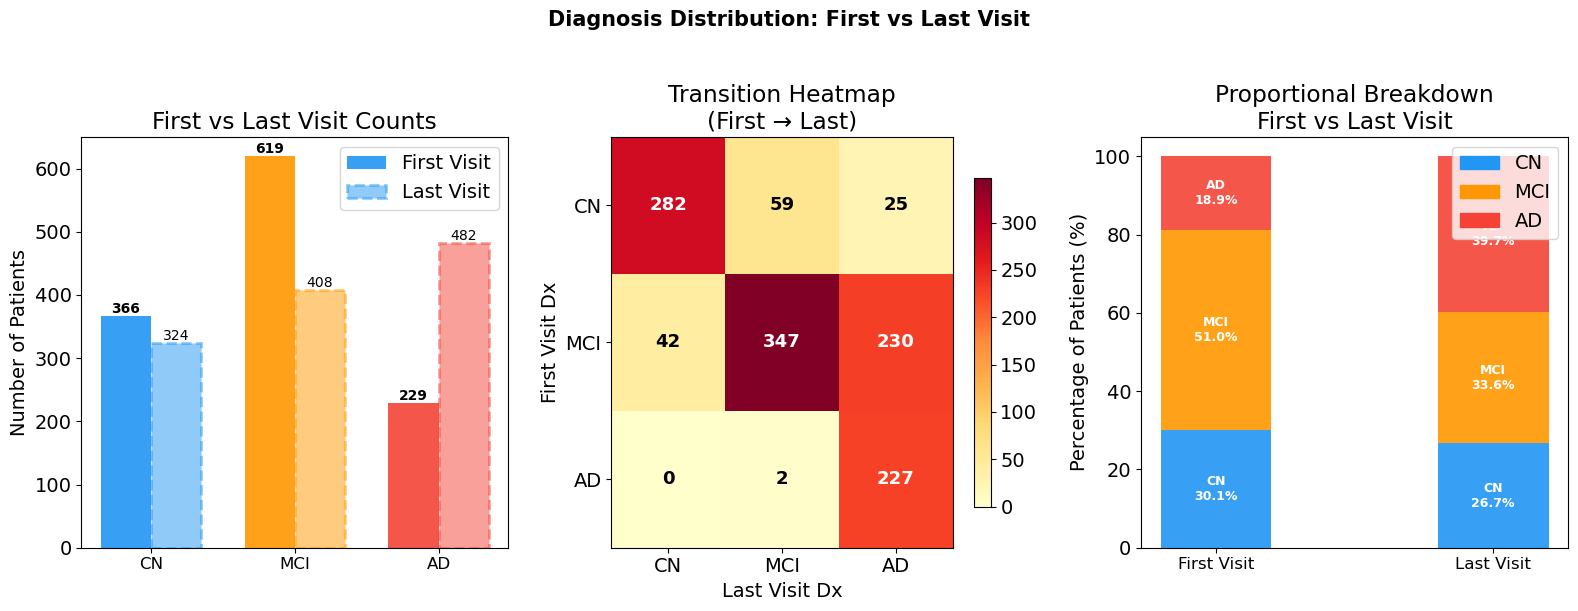

Plot saved.


In [145]:
# ── 1. Merge on RID + VISCODE ──────────────────────────────────────────────

merged = CSF_AD.merge(
    dx_df[['RID', 'VISCODE', 'DIAGNOSIS', "EXAMDATE"]], # add in dementia diagnosis at each visit (CN/MCI/AD)
    on=['RID', 'VISCODE'],
    how='left'
)

diag_map = {1: 'CN', 2: 'MCI', 3: 'AD'}
merged['DIAGNOSIS_LABEL'] = merged['DIAGNOSIS'].map(diag_map)

# ── 2. First & last visit per patient (by days_since_baseline}) ───────────────────
merged_sorted = merged.sort_values(['RID', 'days_since_entry'])

first_visit = merged_sorted.groupby('RID').first().reset_index()
last_visit  = merged_sorted.groupby('RID').last().reset_index()

first_counts = first_visit['DIAGNOSIS_LABEL'].value_counts().reindex(['CN', 'MCI', 'AD'], fill_value=0)
last_counts  = last_visit['DIAGNOSIS_LABEL'].value_counts().reindex(['CN', 'MCI', 'AD'], fill_value=0)

print("=== First Visit Diagnosis ===")
print(first_counts)
print(f"  Missing: {first_visit['DIAGNOSIS_LABEL'].isna().sum()}")

print("\n=== Last Visit Diagnosis ===")
print(last_counts)
print(f"  Missing: {last_visit['DIAGNOSIS_LABEL'].isna().sum()}")

# ── 3. Sankey-style transition counts ─────────────────────────────────────
transitions = merged_sorted.groupby('RID').agg(
    first_dx=('DIAGNOSIS_LABEL', 'first'),
    last_dx=('DIAGNOSIS_LABEL', 'last')
).reset_index()

transition_counts = transitions.groupby(['first_dx', 'last_dx']).size().reset_index(name='count')
print("\n=== Transition counts (first → last) ===")
print(transition_counts.pivot(index='first_dx', columns='last_dx', values='count').fillna(0))

# ── 4. Plot ────────────────────────────────────────────────────────────────
colors = {'CN': '#2196F3', 'MCI': '#FF9800', 'AD': '#F44336'}
categories = ['CN', 'MCI', 'AD']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Diagnosis Distribution: First vs Last Visit', fontsize=15, fontweight='bold', y=1.02)

# — Panel 1: Grouped bar chart —
ax1 = axes[0]
x = np.arange(len(categories))
w = 0.35
bars1 = ax1.bar(x - w/2, [first_counts[c] for c in categories], w,
                label='First Visit', color=[colors[c] for c in categories], alpha=0.9)
bars2 = ax1.bar(x + w/2, [last_counts[c] for c in categories],  w,
                label='Last Visit',  color=[colors[c] for c in categories], alpha=0.5,
                edgecolor=[colors[c] for c in categories], linewidth=2, linestyle='--')
ax1.set_xticks(x); ax1.set_xticklabels(categories, fontsize=12)
ax1.set_ylabel('Number of Patients'); ax1.set_title('First vs Last Visit Counts')
ax1.legend()
for bar in bars1: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

# — Panel 2: Transition heatmap —
ax2 = axes[1]
pivot = transitions.groupby(['first_dx', 'last_dx']).size().unstack(fill_value=0).reindex(
    index=categories, columns=categories, fill_value=0)
im = ax2.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
ax2.set_xticks(range(len(categories))); ax2.set_xticklabels(categories)
ax2.set_yticks(range(len(categories))); ax2.set_yticklabels(categories)
ax2.set_xlabel('Last Visit Dx'); ax2.set_ylabel('First Visit Dx')
ax2.set_title('Transition Heatmap\n(First → Last)')
for i in range(len(categories)):
    for j in range(len(categories)):
        val = pivot.values[i, j]
        ax2.text(j, i, str(int(val)), ha='center', va='center',
                 fontsize=13, fontweight='bold',
                 color='white' if val > pivot.values.max()*0.6 else 'black')
plt.colorbar(im, ax=ax2, shrink=0.8)

# — Panel 3: Stacked % bar —
ax3 = axes[2]
total_first = first_counts.sum()
total_last  = last_counts.sum()
bottom_f = bottom_l = 0
for cat in categories:
    pf = first_counts[cat] / total_first * 100
    pl = last_counts[cat]  / total_last  * 100
    ax3.bar(0, pf, bottom=bottom_f, color=colors[cat], alpha=0.9, width=0.4)
    ax3.bar(1, pl, bottom=bottom_l, color=colors[cat], alpha=0.9, width=0.4)
    if pf > 3: ax3.text(0, bottom_f + pf/2, f'{cat}\n{pf:.1f}%', ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    if pl > 3: ax3.text(1, bottom_l + pl/2, f'{cat}\n{pl:.1f}%', ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    bottom_f += pf; bottom_l += pl
ax3.set_xticks([0, 1]); ax3.set_xticklabels(['First Visit', 'Last Visit'], fontsize=12)
ax3.set_ylabel('Percentage of Patients (%)'); ax3.set_title('Proportional Breakdown\nFirst vs Last Visit')
patches = [mpatches.Patch(color=colors[c], label=c) for c in categories]
ax3.legend(handles=patches, loc='upper right')

plt.tight_layout()
plt.savefig('diagnosis_first_last.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

In [28]:
# ── AD diagnosis date: first visit where DIAGNOSIS_LABEL == 'AD' ───────────
ad_dx_date = (
    merged_sorted[merged_sorted["DIAGNOSIS_LABEL"] == "AD"]
    .groupby("RID")["VISDATE"]
    .first()
    .reset_index()
    .rename(columns={"VISDATE": "AD_dx_date"})
)
ad_dx_date["AD_dx_date"] = pd.to_datetime(ad_dx_date["AD_dx_date"])

print(f"Individuals with an AD diagnosis date: {len(ad_dx_date)}")

Individuals with an AD diagnosis date: 495


In [29]:
# ── Group 1: All patients ──────────────────────────────────────────────────
df_all = CSF_AD.merge(
    transitions[['RID', 'first_dx', 'last_dx']],
    on='RID', how='left'
).merge(ad_dx_date, on='RID', how='left')

print(f"Group 1 - All patients:          n = {df_all['RID'].nunique()} patients, {len(df_all)} rows")

# ── Group 2: End up as MCI or AD at last visit ─────────────────────────────
progressors_rid = transitions[transitions['last_dx'].isin(['MCI', 'AD'])]['RID']
df_progressors = CSF_AD[CSF_AD['RID'].isin(progressors_rid)].merge(
    transitions[['RID', 'first_dx', 'last_dx']], on='RID', how='left'
).merge(ad_dx_date, on='RID', how='left')

print(f"Group 2 - End MCI or AD:         n = {df_progressors['RID'].nunique()} patients, {len(df_progressors)} rows")

# ── Group 3: End up as AD at last visit ────────────────────────────────────
ad_converters_rid = transitions[transitions['last_dx'] == 'AD']['RID']
df_ad_converters = CSF_AD[CSF_AD['RID'].isin(ad_converters_rid)].merge(
    transitions[['RID', 'first_dx', 'last_dx']], on='RID', how='left'
).merge(ad_dx_date, on='RID', how='left')

print(f"Group 3 - End AD:                n = {df_ad_converters['RID'].nunique()} patients, {len(df_ad_converters)} rows")

# ── Group 4: AD at entry — use baseline VISDATE as proxy for AD dx date ────
ad_at_entry_rid = transitions[transitions['first_dx'] == 'AD']['RID']
df_ad_entry = CSF_AD[CSF_AD['RID'].isin(ad_at_entry_rid)].merge(
    transitions[['RID', 'first_dx', 'last_dx']], on='RID', how='left'
).merge(ad_dx_date, on='RID', how='left')

print(f"Group 4 - AD at entry:           n = {df_ad_entry['RID'].nunique()} patients, {len(df_ad_entry)} rows")

# ── Group 5: MCI converters — start CN or MCI, end as AD ──────────────────
mci_converters_rid = transitions[
    (transitions['last_dx'] == 'AD') &
    (transitions['first_dx'].isin(['CN', 'MCI']))
]['RID']
df_mci_converters = CSF_AD[CSF_AD['RID'].isin(mci_converters_rid)].merge(
    transitions[['RID', 'first_dx', 'last_dx']], on='RID', how='left'
).merge(ad_dx_date, on='RID', how='left')

print(f"Group 5 - MCI converters:        n = {df_mci_converters['RID'].nunique()} patients, {len(df_mci_converters)} rows")

# ── Coverage check ─────────────────────────────────────────────────────────
print("\n=== AD diagnosis date coverage per group ===")
for name, df in [("All", df_all), ("End MCI/AD", df_progressors),
                 ("End AD", df_ad_converters), ("AD at entry", df_ad_entry),
                 ("MCI converters", df_mci_converters)]:
    n_pts = df['RID'].nunique()
    n_dated = df.drop_duplicates('RID')['AD_dx_date'].notna().sum()
    print(f"{name}: {n_dated}/{n_pts} have AD_dx_date ({n_dated/n_pts*100:.1f}%)")

Group 1 - All patients:          n = 1214 patients, 7043 rows
Group 2 - End MCI or AD:         n = 890 patients, 4985 rows
Group 3 - End AD:                n = 482 patients, 2487 rows
Group 4 - AD at entry:           n = 229 patients, 724 rows
Group 5 - MCI converters:        n = 255 patients, 1769 rows

=== AD diagnosis date coverage per group ===
All: 495/1214 have AD_dx_date (40.8%)
End MCI/AD: 495/890 have AD_dx_date (55.6%)
End AD: 482/482 have AD_dx_date (100.0%)
AD at entry: 229/229 have AD_dx_date (100.0%)
MCI converters: 255/255 have AD_dx_date (100.0%)


In [30]:
dem = pd.read_csv('data/PTDEMOG_17Feb2026.csv')
dem["USERDATE"] = pd.to_datetime(dem["USERDATE"], errors="coerce")
dem_unique = (
    dem.sort_values("USERDATE")
    .groupby("RID")
    .first()
    .reset_index()
)

# ── Extract pre-study AD date for AD-at-entry individuals ──────────────────
start_ad_individuals = df_ad_entry[["RID"]].drop_duplicates()
recent_AD = start_ad_individuals.merge(dem_unique, on="RID", how="left")

print(f"N individuals: {recent_AD['RID'].nunique()}")
print(f"N rows: {len(recent_AD)}")
recent_AD["PTADBEG"] = recent_AD["PTADBEG"].astype(str).str.strip()
recent_AD["PTADDX"]  = recent_AD["PTADDX"].astype(str).str.strip()

# Prefer formal diagnosis year, fall back to symptom onset year
recent_AD["AD_date_raw"] = np.where(
    recent_AD["PTADDX"].str.startswith(("1", "2")),
    recent_AD["PTADDX"],
    recent_AD["PTADBEG"]
)

# Check source breakdown before converting
using_ptaddx  = recent_AD["PTADDX"].str.startswith(("1", "2")).sum()
using_ptadbeg = (~recent_AD["PTADDX"].str.startswith(("1", "2")) &
                  recent_AD["PTADBEG"].str.startswith(("1", "2"))).sum()
neither       = (~recent_AD["PTADDX"].str.startswith(("1", "2")) &
                 ~recent_AD["PTADBEG"].str.startswith(("1", "2"))).sum()

print(f"Using PTADDX (formal dx):        {using_ptaddx}")
print(f"Falling back to PTADBEG:         {using_ptadbeg}")
print(f"No valid date (will be dropped): {neither}")

# Safe numeric conversion — non-parseable values become NaT
year_series = pd.to_numeric(recent_AD["AD_date_raw"], errors="coerce")

recent_AD["AD_dx_date_prestudy"] = pd.to_datetime(
    year_series.dropna().astype(int).astype(str) + "-07-01",
    format="%Y-%m-%d",
    errors="coerce"
).reindex(recent_AD.index)  # re-align index after dropna

print(f"\nPre-study AD date coverage: {recent_AD['AD_dx_date_prestudy'].notna().sum()} / {len(recent_AD)}")

# Drop if already exists from a previous run
df_ad_entry = df_ad_entry.drop(columns=["AD_dx_date_prestudy", "AD_dx_date"], errors="ignore")

df_ad_entry = df_ad_entry.merge(
    recent_AD[["RID", "AD_dx_date_prestudy"]],
    on="RID", how="left"
)

df_ad_entry["AD_dx_date"] = df_ad_entry["AD_dx_date_prestudy"]

n_before = df_ad_entry["RID"].nunique()
df_ad_entry = df_ad_entry[df_ad_entry["AD_dx_date"].notna()]
n_after = df_ad_entry["RID"].nunique()

print(f"AD-at-entry individuals retained:  {n_after}")
print(f"Discarded (no valid date):         {n_before - n_after}")

N individuals: 229
N rows: 229
Using PTADDX (formal dx):        126
Falling back to PTADBEG:         96
No valid date (will be dropped): 7

Pre-study AD date coverage: 222 / 229
AD-at-entry individuals retained:  222
Discarded (no valid date):         7


In [31]:
# ── Build a clean RID-level AD date lookup from both sources ───────────────

# Source 1: pre-study dates for AD-at-entry (already derived above)
ad_entry_dates = (
    df_ad_entry[["RID", "AD_dx_date"]]
    .drop_duplicates("RID")
)

# Source 2: VISDATE of first AD visit for MCI converters
converter_dates = (
    df_mci_converters[["RID", "AD_dx_date"]]
    .drop_duplicates("RID")
)

# Combine — these groups are mutually exclusive so no conflict
ad_date_lookup = pd.concat([ad_entry_dates, converter_dates], ignore_index=True)

print(f"Total individuals with AD date: {ad_date_lookup['RID'].nunique()}")

# ── Merge onto df_ad_converters ────────────────────────────────────────────
# Drop any existing AD_dx_date column first to avoid suffix conflicts
if "AD_dx_date" in df_ad_converters.columns:
    df_ad_converters = df_ad_converters.drop(columns=["AD_dx_date"])

df_ad_converters = df_ad_converters.merge(
    ad_date_lookup,
    on="RID",
    how="right"
)

# ── Sanity check ───────────────────────────────────────────────────────────
n = df_ad_converters["RID"].nunique()
dated = df_ad_converters.drop_duplicates("RID")["AD_dx_date"].notna().sum()
print(f"df_ad_converters: {dated}/{n} individuals have a valid AD_dx_date")



Total individuals with AD date: 477
df_ad_converters: 477/477 individuals have a valid AD_dx_date


### Identify pre-diagnosis medical conditions:

In [41]:
UTI_KEYWORDS = [
    "urinary tract infection",
    "uti",
]

GI_KEYWORDS = [
    "diarrhea",
    "constipation",
    "halitosis",
    "fecal incontinence",
    "abnormal bowel movement",
    "abnormal bowel sounds",
    "encopresis",
]

SLEEP_KEYWORDS = [
    "insomnia",
    "sleep disorder",
    "sleep disturbance",
    "poor sleep",
    "sleep apnea",
    "obstructive sleep apnea",
    "osa",
    "hypersomnia",
    "sleep fragmentation",
    "restless legs",
    "bruxism",
    "parasomnia",
    "narcolepsy", 
]

CHRONIC_GI_KEYWORDS = [
    "chronic diarrhea",
    "chronic constipation",
    "frequent diarrhea",
    "frequent constipation",
    "occasional diarrhea",
    "occasional constipation",
    "intermittent diarrhea",
    "intermittent constipation",
    "history of diarrhea",
    "history of constipation",
]


In [61]:
SPECIFIC_KEYWORDS = {
    "UTI": UTI_KEYWORDS,
    "GI": GI_KEYWORDS,
    "Sleep": SLEEP_KEYWORDS,
}

# Function to standardise and classify specific conditions based on keywords
def classify_specific(desc):

    if pd.isna(desc):
        return None
    
    
    d = desc.lower()
    d = d.replace("hx of", "history of")
    d = d.replace("h/o", "history of")
    
    for category, keywords in SPECIFIC_KEYWORDS.items():
        if any(k in d for k in keywords):
            return category
    
    return None

recmhist["specific_flag"] = recmhist["MHDESC"].apply(classify_specific)

### Consider all medical history up to AD diagnosis for CN and MCI converters

In [122]:
# ── Build RID-level AD date lookup from df_ad_converters ──────────────────
ad_date_lookup = (
    df_ad_converters[["RID", "AD_dx_date"]]
    .drop_duplicates("RID")
)

# ── Merge AD date onto recmhist and filter to pre-AD visits ───────────────
recmhist["VISDATE"] = pd.to_datetime(recmhist["VISDATE"], errors="coerce")

recmhist_with_date = recmhist.merge(ad_date_lookup, on="RID", how="inner")

# Keep only visits where the condition was recorded before AD diagnosis
recmhist_pre_ad = recmhist_with_date[
    recmhist_with_date["VISDATE"] < recmhist_with_date["AD_dx_date"]
]

print(f"Individuals in recmhist with AD date:     {recmhist_with_date['RID'].nunique()}")
print(f"Individuals with pre-AD recmhist entries: {recmhist_pre_ad['RID'].nunique()}")

# ── Apply keyword classification ───────────────────────────────────────────
recmhist_pre_ad = recmhist_pre_ad.copy()
recmhist_pre_ad["specific_flag"] = recmhist_pre_ad["MHDESC"].apply(classify_specific)

# ── Collapse to one row per RID with binary flags ─────────────────────────
# Any pre-AD visit with a flagged condition counts as a positive
specific_flags_pre_ad = (
    recmhist_pre_ad[recmhist_pre_ad["specific_flag"].notna()]
    .assign(flag=1)
    .pivot_table(
        index="RID",
        columns="specific_flag",
        values="flag",
        aggfunc="max",
        fill_value=0
    )
    .reset_index()
)

# ── Print GI-positive MHDESC descriptions ─────────────────────────────────
gi_positive = (
    recmhist_pre_ad[recmhist_pre_ad["specific_flag"] == "GI"]
    [["RID", "VISDATE", "MHDESC"]]
    .drop_duplicates()
    .sort_values(["RID", "VISDATE"])
)

print(f"\nGI-positive descriptions (n={gi_positive['RID'].nunique()} unique RIDs, "
      f"{len(gi_positive)} total entries):")
print(gi_positive["MHDESC"].value_counts().to_string())

# Ensure all three columns exist even if no cases found
for col in ["UTI", "GI", "Sleep"]:
    if col not in specific_flags_pre_ad.columns:
        specific_flags_pre_ad[col] = 0

print(f"\nPre-AD condition prevalence:")
for col in ["UTI", "GI", "Sleep"]:
    n = specific_flags_pre_ad[col].sum()
    pct = n / ad_date_lookup["RID"].nunique() * 100
    print(f"  {col}: {n} ({pct:.1f}%)")

# ── Merge onto df_ad_converters ───────────────────────────────────────────
# Drop existing condition columns if re-running to avoid suffix conflicts
for col in ["UTI", "GI", "Sleep"]:
    if col in df_ad_converters.columns:
        df_ad_converters = df_ad_converters.drop(columns=[col])

df_ad_converters = df_ad_converters.merge(
    specific_flags_pre_ad[["RID", "UTI", "GI", "Sleep"]],
    on="RID",
    how="left"
)

# Individuals with no matching recmhist entries get 0 (no flagged condition)
for col in ["UTI", "GI", "Sleep"]:
    df_ad_converters[col] = df_ad_converters[col].fillna(0).astype(int)

# ── Sanity check ──────────────────────────────────────────────────────────
print(f"\ndf_ad_converters condition flags:")
for col in ["UTI", "GI", "Sleep"]:
    n = df_ad_converters.drop_duplicates("RID")[col].sum()
    print(f"  {col}: {n}")

Individuals in recmhist with AD date:     431
Individuals with pre-AD recmhist entries: 261

GI-positive descriptions (n=22 unique RIDs, 33 total entries):
MHDESC
Constipation                                                                                                                                           5
Constipation (2003)                                                                                                                                    2
constipation                                                                                                                                           2
chronic constipation                                                                                                                                   2
Diarrhea                                                                                                                                               2
diarrhea related to aricept --/--/2003                                  

### Explore pre-AD conditions in the AD at entry cohort and categorise by ambiguity

In [123]:
import re
import numpy as np
import pandas as pd

# ── AD-at-entry RIDs with their pre-study AD diagnosis date ───────────────
ad_entry_date_lookup = (
    df_ad_entry[["RID", "AD_dx_date"]]
    .drop_duplicates("RID")
)

# ── Filter recmhist to AD-at-entry individuals only ───────────────────────
recmhist_ad_entry = recmhist.merge(ad_entry_date_lookup, on="RID", how="inner")
recmhist_ad_entry["specific_flag"] = recmhist_ad_entry["MHDESC"].apply(classify_specific)

# Only process rows with a relevant condition flag
recmhist_ad_entry_flagged = recmhist_ad_entry[
    recmhist_ad_entry["specific_flag"].notna()
].copy()

print(f"AD-at-entry individuals in recmhist:         {recmhist_ad_entry['RID'].nunique()}")
print(f"AD-at-entry flagged condition entries:       {len(recmhist_ad_entry_flagged)}")

# ── NLP date extraction from free text ────────────────────────────────────

def extract_years_from_text(text: str) -> list[int]:
    """Extract all plausible calendar years from free text."""
    if pd.isna(text):
        return []
    years = re.findall(r'\b(19\d{2}|20[0-2]\d)\b', str(text))
    return [int(y) for y in years]


def extract_age_onset_year(text: str, birth_year: int | None) -> int | None:
    """Convert age-based references (e.g. 'onset age 12') to calendar year."""
    if pd.isna(text) or birth_year is None:
        return None
    age_match = re.search(r'\bage\s+(\d{1,2})\b', str(text), re.IGNORECASE)
    if age_match:
        return birth_year + int(age_match.group(1))
    if re.search(r'\bchildhood\b', str(text), re.IGNORECASE):
        return birth_year + 10
    return None


def classify_text_timing(
    text: str,
    ad_dx_year: int,
    birth_year: int | None = None,
    grace_period: int = 1
) -> str:
    """
    Classify a free-text entry as pre_AD, post_AD, ambiguous, or undated
    relative to the AD diagnosis year.
    """
    if pd.isna(text):
        return "undated"

    years = extract_years_from_text(text)

    if birth_year:
        age_year = extract_age_onset_year(text, birth_year)
        if age_year:
            years.append(age_year)

    if not years:
        return "undated"

    earliest = min(years)
    latest   = max(years)

    if latest < (ad_dx_year - grace_period):
        return "pre_AD"
    elif earliest > (ad_dx_year + grace_period):
        return "post_AD"
    else:
        return "ambiguous"


# ── Apply classification ───────────────────────────────────────────────────
recmhist_ad_entry_flagged["AD_dx_year"] = pd.to_datetime(
    recmhist_ad_entry_flagged["AD_dx_date"]
).dt.year

recmhist_ad_entry_flagged["text_timing"] = recmhist_ad_entry_flagged.apply(
    lambda row: classify_text_timing(
        text=row["MHDESC"],
        ad_dx_year=int(row["AD_dx_year"]),
    ),
    axis=1
)

# ── Timing breakdown audit ─────────────────────────────────────────────────
print("\nTiming classification breakdown:")
print(
    recmhist_ad_entry_flagged
    .groupby(["specific_flag", "text_timing"])
    .size()
    .unstack(fill_value=0)
)

# ── Print GI-positive MHDESC descriptions by timing classification ─────────
gi_flagged = recmhist_ad_entry_flagged[recmhist_ad_entry_flagged["specific_flag"] == "GI"].copy()

print(f"\nGI-positive descriptions (n={gi_flagged['RID'].nunique()} unique RIDs, "
      f"{len(gi_flagged)} total entries):")

for timing, group in gi_flagged.groupby("text_timing"):
    print(f"\n  [{timing}] — {group['RID'].nunique()} RIDs, {len(group)} entries:")
    print(group["MHDESC"].value_counts().to_string())
    
# ── Collapse to RID-level flags (pre_AD and undated as primary analysis) ───
# Primary: pre_AD only
pre_ad_flags = (
    recmhist_ad_entry_flagged[recmhist_ad_entry_flagged["text_timing"] == "pre_AD"]
    .assign(flag=1)
    .pivot_table(
        index="RID",
        columns="specific_flag",
        values="flag",
        aggfunc="max",
        fill_value=0
    )
    .reset_index()
)

# Sensitivity: pre_AD + undated
pre_ad_undated_flags = (
    recmhist_ad_entry_flagged[
        recmhist_ad_entry_flagged["text_timing"].isin(["pre_AD", "undated"])
    ]
    .assign(flag=1)
    .pivot_table(
        index="RID",
        columns="specific_flag",
        values="flag",
        aggfunc="max",
        fill_value=0
    )
    .reset_index()
)

# Ensure all condition columns present
for col in ["UTI", "GI", "Sleep"]:
    for df in [pre_ad_flags, pre_ad_undated_flags]:
        if col not in df.columns:
            df[col] = 0

print(f"\nPrimary (pre_AD only) — individuals flagged:")
for col in ["UTI", "GI", "Sleep"]:
    print(f"  {col}: {pre_ad_flags[col].sum()}")

print(f"\nSensitivity (pre_AD + undated) — individuals flagged:")
for col in ["UTI", "GI", "Sleep"]:
    print(f"  {col}: {pre_ad_undated_flags[col].sum()}")

# ── Merge primary flags onto df_ad_entry ──────────────────────────────────
for col in ["UTI", "GI", "Sleep"]:
    if col in df_ad_entry.columns:
        df_ad_entry = df_ad_entry.drop(columns=[col])

df_ad_entry = df_ad_entry.merge(
    pre_ad_flags[["RID", "UTI", "GI", "Sleep"]],
    on="RID", how="left"
)

for col in ["UTI", "GI", "Sleep"]:
    df_ad_entry[col] = df_ad_entry[col].fillna(0).astype(int)

print(f"\ndf_ad_entry condition flags (primary, pre_AD only):")
for col in ["UTI", "GI", "Sleep"]:
    n = df_ad_entry.drop_duplicates("RID")[col].sum()
    pct = n / df_ad_entry["RID"].nunique() * 100
    print(f"  {col}: {n} ({pct:.1f}%)")

AD-at-entry individuals in recmhist:         222
AD-at-entry flagged condition entries:       71

Timing classification breakdown:
text_timing    ambiguous  post_AD  pre_AD  undated
specific_flag                                     
GI                     2        4       4        8
Sleep                  4        2       6       36
UTI                    1        0       1        3

GI-positive descriptions (n=18 unique RIDs, 18 total entries):

  [ambiguous] — 2 RIDs, 2 entries:
MHDESC
gastric reflux (1998), occasional diarrhea (2005)                                                             1
Intermittent Diarrhea (Frequently) Possibly Related to Medication (Aricept). Onset: JANUARY 2006 - Ongoing    1

  [post_AD] — 4 RIDs, 4 entries:
MHDESC
Diarrhea and constipation -resolved in 2004       1
Occational diarrhea 2004, secondary to Aricept    1
Diarrhea (2005)                                   1
Frequent constipation since April 2006            1

  [pre_AD] — 4 RIDs, 4 entries:
M

In [64]:
# ── Build per-RID timing summary for AD-at-entry individuals ──────────────
# For each RID + condition, what is the most favourable classification?
# (pre_AD > undated > ambiguous > post_AD)

timing_priority = {"pre_AD": 0, "undated": 1, "ambiguous": 2, "post_AD": 3}

recmhist_ad_entry_flagged["timing_priority"] = (
    recmhist_ad_entry_flagged["text_timing"].map(timing_priority)
)

# Best (lowest priority number) classification per RID per condition
best_timing = (
    recmhist_ad_entry_flagged[recmhist_ad_entry_flagged["specific_flag"].notna()]
    .sort_values("timing_priority")
    .groupby(["RID", "specific_flag"])
    .first()
    .reset_index()[["RID", "specific_flag", "text_timing"]]
)

# ── Helper: build wide flags given allowed timings ────────────────────────
def build_flag_df(best_timing_df, allowed_timings):
    flags = (
        best_timing_df[best_timing_df["text_timing"].isin(allowed_timings)]
        .assign(flag=1)
        .pivot_table(
            index="RID",
            columns="specific_flag",
            values="flag",
            aggfunc="max",
            fill_value=0
        )
        .reset_index()
    )
    for col in ["UTI", "GI", "Sleep"]:
        if col not in flags.columns:
            flags[col] = 0
    return flags

# ── Derive flags under each assumption ────────────────────────────────────
pre_ad_strict_flags  = build_flag_df(best_timing, allowed_timings=["pre_AD"])
pre_ad_undated_flags = build_flag_df(best_timing, allowed_timings=["pre_AD", "undated"])

# ── Individuals to EXCLUDE from each dataframe ────────────────────────────
# Strict: exclude any RID whose ONLY flagged entries are ambiguous/post_AD/undated
# i.e. they have a condition flag but none of their entries are confirmed pre_AD

all_flagged_rids = set(recmhist_ad_entry_flagged["RID"].unique())
strict_valid_rids = set(pre_ad_strict_flags[
    pre_ad_strict_flags[["UTI", "GI", "Sleep"]].max(axis=1) > 0
]["RID"])

# RIDs with flagged conditions but none confirmed pre_AD — excluded from strict df
ambiguous_only_rids = all_flagged_rids - strict_valid_rids

print(f"RIDs with conditions but none confirmed pre_AD (excluded from strict): "
      f"{len(ambiguous_only_rids)}")

# ── DataFrame 1: STRICT — pre_AD confirmed only ───────────────────────────
# Drop ambiguous/post_AD/undated flagged individuals entirely
# Individuals with NO flagged conditions at all are retained (genuinely comorbidity-free)

for col in ["UTI", "GI", "Sleep"]:
    if col in df_ad_entry.columns:
        df_ad_entry = df_ad_entry.drop(columns=[col])

df_ad_entry_strict = (
    df_ad_entry[~df_ad_entry["RID"].isin(ambiguous_only_rids)]
    .merge(pre_ad_strict_flags[["RID", "UTI", "GI", "Sleep"]], on="RID", how="left")
)
for col in ["UTI", "GI", "Sleep"]:
    df_ad_entry_strict[col] = df_ad_entry_strict[col].fillna(0).astype(int)

for col in ["UTI", "GI", "Sleep"]:
    n = df_ad_entry_strict.drop_duplicates("RID")[col].sum()
    pct = n / df_ad_entry_strict["RID"].nunique() * 100
    

# ── DataFrame 2: INCLUSIVE — pre_AD + undated ─────────────────────────────
# Undated entries treated as valid pre_AD; only post_AD and ambiguous excluded
# RIDs whose only flags are post_AD or ambiguous are dropped

inclusive_valid_rids = set(pre_ad_undated_flags[
    pre_ad_undated_flags[["UTI", "GI", "Sleep"]].max(axis=1) > 0
]["RID"])
post_ambiguous_only_rids = all_flagged_rids - inclusive_valid_rids

df_ad_entry_inclusive = (
    df_ad_entry[~df_ad_entry["RID"].isin(post_ambiguous_only_rids)]
    .merge(pre_ad_undated_flags[["RID", "UTI", "GI", "Sleep"]], on="RID", how="left")
)
for col in ["UTI", "GI", "Sleep"]:
    df_ad_entry_inclusive[col] = df_ad_entry_inclusive[col].fillna(0).astype(int)


for col in ["UTI", "GI", "Sleep"]:
    n = df_ad_entry_inclusive.drop_duplicates("RID")[col].sum()
    pct = n / df_ad_entry_inclusive["RID"].nunique() * 100
    



RIDs with conditions but none confirmed pre_AD (excluded from strict): 45


In [65]:
# ── RID-level flags per source ─────────────────────────────────────────────
df_mci_converters = df_ad_converters[df_ad_converters["RID"].isin(df_mci_converters["RID"])]

mci_flags = (
    df_ad_converters[df_ad_converters["RID"].isin(df_mci_converters["RID"])]
    .drop_duplicates("RID")[["RID", "UTI", "GI", "Sleep"]]
)
entry_strict_flags = df_ad_entry_strict.drop_duplicates("RID")[["RID", "UTI", "GI", "Sleep"]]
entry_inclusive_flags = df_ad_entry_inclusive.drop_duplicates("RID")[["RID", "UTI", "GI", "Sleep"]]

# ── Drop existing condition columns ───────────────────────────────────────
df_ad_converters = df_ad_converters.drop(columns=["UTI", "GI", "Sleep"], errors="ignore")

# ── Build the two dataframes ───────────────────────────────────────────────
df_ad_converters_strict = df_ad_converters.merge(
    pd.concat([mci_flags, entry_strict_flags], ignore_index=True),
    on="RID", how="inner"
)

df_ad_converters_inclusive = df_ad_converters.merge(
    pd.concat([mci_flags, entry_inclusive_flags], ignore_index=True),
    on="RID", how="inner"
)

# ── Summary ────────────────────────────────────────────────────────────────
for name, df in [("Strict", df_ad_converters_strict), ("Inclusive", df_ad_converters_inclusive)]:
    print(f"\n{name}: {df['RID'].nunique()} individuals")
    for col in ["UTI", "GI", "Sleep"]:
        n = df.drop_duplicates("RID")[col].sum()
        print(f"  {col}: {n} ({n/df['RID'].nunique()*100:.1f}%)")


Strict: 432 individuals
  UTI: 11 (2.5%)
  GI: 26 (6.0%)
  Sleep: 56 (13.0%)

Inclusive: 432 individuals
  UTI: 11 (2.5%)
  GI: 26 (6.0%)
  Sleep: 56 (13.0%)


In [66]:
# ── Prep medhist flags ─────────────────────────────────────────────────────
medhist_sub = medhist[["RID", "VISCODE", "VISDATE", "MH10GAST", "MH12RENA"]].copy()
medhist_sub[["MH10GAST", "MH12RENA"]] = medhist_sub[["MH10GAST", "MH12RENA"]].applymap(lambda x: 1 if x == 1 else 0)
medhist_sub = medhist_sub.rename(columns={"MH10GAST": "GI_broad", "MH12RENA": "UTI_broad"})
medhist_sub["VISDATE"] = pd.to_datetime(medhist_sub["VISDATE"], errors="coerce")

# ── Merge AD date and filter to pre-AD visits ──────────────────────────────
ad_date_lookup = df_mci_converters.drop_duplicates("RID")[["RID", "AD_dx_date"]]

broad_flags = (
    medhist_sub
    .merge(ad_date_lookup, on="RID", how="inner")
    .query("VISDATE < AD_dx_date")
    .groupby("RID")[["GI_broad", "UTI_broad"]]
    .max()
    .reset_index()
)

# ── Merge onto MCI converter flags ────────────────────────────────────────
df_mci_converters = (
    df_mci_converters
    .merge(broad_flags, on="RID", how="left")
)

mci_flags_broad = (
    mci_flags
    .merge(broad_flags, on="RID", how="left")
)
for col in ["GI_broad", "UTI_broad"]:
    mci_flags_broad[col] = mci_flags_broad[col].fillna(0).astype(int)

print(mci_flags_broad[["UTI", "GI", "UTI_broad", "GI_broad"]].sum())

UTI           10
GI            22
UTI_broad    118
GI_broad     110
dtype: int64


/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_89371/663226192.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  medhist_sub[["MH10GAST", "MH12RENA"]] = medhist_sub[["MH10GAST", "MH12RENA"]].applymap(lambda x: 1 if x == 1 else 0)


In [67]:
df_ad_converters = df_ad_converters_strict.copy()

In [68]:
# Last visit per patient
last_visit_ad = (
    df_ad_converters
    .sort_values(['RID', 'days_since_entry'])
    .groupby('RID')
    .last()
    .reset_index()
)

# Convert to years
last_visit_ad['years_since_entry'] = last_visit_ad['days_since_entry'] / 365.25

# Average follow-up time
avg_years = last_visit_ad['years_since_entry'].mean()

print(f"Average time from baseline to last visit (AD converters): {avg_years:.2f} years")

Average time from baseline to last visit (AD converters): 3.64 years


In [78]:
# Check proportion of inidividuals with comorbidities of interest

for df, name in [ (df_ad_converters, "End with AD"), (df_mci_converters, "Convert to AD")]:
    print(f"\n=== {name} (n={df['RID'].nunique()}) ===")

    if "UTI_broad" in df.columns and "GI_broad" in df.columns:
        for condition in ["UTI", "UTI_broad", "GI", "GI_broad", "Sleep"]:
            n = df[df[condition] == 1]["RID"].nunique()
            print(f"  {condition}: {n} patients ({100*n/df['RID'].nunique():.1f}%)")

    else:
        for condition in ["UTI", "GI", "Sleep"]:
            n = df[df[condition] == 1]["RID"].nunique()
            print(f"  {condition}: {n} patients ({100*n/df['RID'].nunique():.1f}%)")


=== End with AD (n=431) ===
  UTI: 11 patients (2.6%)
  GI: 26 patients (6.0%)
  Sleep: 56 patients (13.0%)

=== Convert to AD (n=255) ===
  UTI: 10 patients (3.9%)
  UTI_broad: 118 patients (46.3%)
  GI: 22 patients (8.6%)
  GI_broad: 110 patients (43.1%)
  Sleep: 50 patients (19.6%)


In [79]:
# Drop rows with NaN
print(f"Before dropna: {len(df_ad_converters)} rows")
df_ad_converters = df_ad_converters.dropna()
print(f"After dropna: {len(df_ad_converters)} rows")

# Verify no NaNs remain
nan_check = df_ad_converters.isna().sum().sum()
print(f"Remaining NaNs: {nan_check}")


print(f"\nBefore dropna (mci): {len(df_mci_converters)} rows")
df_mci_converters = df_mci_converters.dropna()
print(f"After dropna (mci): {len(df_mci_converters)} rows")

print("\n✓ Complete null rows removed successfully")

Before dropna: 2333 rows
After dropna: 2333 rows
Remaining NaNs: 0

Before dropna (mci): 1769 rows
After dropna (mci): 1769 rows

✓ Complete null rows removed successfully


### Cohort demographic summary and Keyword matching analysis

In [80]:
def print_demographic_summary(df, n=397):
    
    # Deduplicate to one row per participant (baseline visit)
    df_baseline = df.sort_values('days_since_entry').groupby('RID').first().reset_index()
    n = len(df_baseline)  # recalculate from unique participants
    
    print(f"Table 1. Demographic Characteristics (n={n})")
    print("=" * 45)
    
    # --- Continuous: Age at Baseline ---
    age = df_baseline['age_at_baseline'].dropna()
    print(f"\nAge at baseline (years)")
    print(f"  Mean (SD): {age.mean():.1f} ({age.std():.1f})")
    
    # --- Continuous: Education ---
    edu = df_baseline['PTEDUCAT'].dropna()
    print(f"\nEducation (years)")
    print(f"  Mean (SD): {edu.mean():.1f} ({edu.std():.1f})")
    
    # --- Categorical: Sex ---
    print(f"\nSex, n (%)")
    sex_map = {1: 'Male', 2: 'Female'}
    for code, label in sex_map.items():
        cnt = (df_baseline['PTGENDER'] == code).sum()
        print(f"  {label}: {cnt} ({cnt/n*100:.1f}%)")
    
    # --- Categorical: Ethnicity ---
    print(f"\nEthnicity, n (%)")
    for cat, cnt in df_baseline['PTETHCAT'].value_counts().items():
        print(f"  {cat}: {cnt} ({cnt/n*100:.1f}%)")
    
    # --- Categorical: Race ---
    print(f"\nRace, n (%)")
    for cat, cnt in df_baseline['PTRACCAT'].value_counts().items():
        print(f"  {cat}: {cnt} ({cnt/n*100:.1f}%)")
    
    # --- Categorical: APOE Carrier ---
    print(f"\nAPOE ε4 Carrier, n (%)")
    for val, label in [(1, 'Carrier'), (0, 'Non-carrier')]:
        cnt = (df_baseline['CARRIER'] == val).sum()
        print(f"  {label}: {cnt} ({cnt/n*100:.1f}%)")
    
    # --- Categorical: APOE Homozygous ---
    print(f"\nAPOE ε4 Homozygous, n (%)")
    for val, label in [(1, 'Homozygous'), (0, 'Non-homozygous')]:
        cnt = (df_baseline['HOMO'] == val).sum()
        print(f"  {label}: {cnt} ({cnt/n*100:.1f}%)")
    
    print("\n" + "=" * 45)

print_demographic_summary(df_ad_converters)

Table 1. Demographic Characteristics (n=431)

Age at baseline (years)
  Mean (SD): 74.1 (7.5)

Education (years)
  Mean (SD): 15.8 (2.8)

Sex, n (%)
  Male: 254 (58.9%)
  Female: 177 (41.1%)

Ethnicity, n (%)
  2.0: 420 (97.4%)
  1.0: 9 (2.1%)
  3.0: 2 (0.5%)

Race, n (%)
  5.0: 414 (96.1%)
  4.0: 8 (1.9%)
  2.0: 7 (1.6%)
  6.0: 2 (0.5%)

APOE ε4 Carrier, n (%)
  Carrier: 266 (61.7%)
  Non-carrier: 165 (38.3%)

APOE ε4 Homozygous, n (%)
  Homozygous: 81 (18.8%)
  Non-homozygous: 350 (81.2%)



In [81]:
# String prevalences: 

# Step 1: Get the raw keyword-level hits from recmhist
# Your recmhist likely has a column that stores the matched keyword string
# Adjust 'keyword_matched' to whatever column holds the actual string (e.g. 'MHTERM', 'keyword', etc.)
recmhist_bl = recmhist[recmhist["VISCODE"].isin(["v01", "sc"])]

KEYWORD_MAP = {
    "GU_591": ["urinary tract infection", "uti"],
    "GI_529": ["diarrhea", "constipation", "halitosis", "fecal incontinence",
                "abnormal bowel movement", "abnormal bowel sounds", "encopresis"],
    "NS_333": ["insomnia", "sleep disorder", "sleep disturbance", "poor sleep",
                "sleep apnea", "obstructive sleep apnea", "osa", "hypersomnia",
                "sleep fragmentation", "restless legs", "bruxism", "parasomnia", "narcolepsy"],
}

# Reverse map: keyword -> phecode group
keyword_to_group = {
    kw: group for group, keywords in KEYWORD_MAP.items() for kw in keywords
}

# Step 2: Filter recmhist to converters only
converters_rids = set(df_ad_converters["RID"])
recmhist_converters = recmhist_bl[recmhist_bl["RID"].isin(converters_rids)].copy()

# Step 3: Normalise the free-text field and match keywords
# Replace 'MHTERM' with whichever column holds the raw text
recmhist_converters["term_lower"] = recmhist_converters["MHDESC"].str.lower().str.strip()

recmhist_converters["keyword_matched"] = recmhist_converters["term_lower"].apply(
    lambda x: next((kw for kw in keyword_to_group if kw in str(x)), None)
)

# Step 4: Keep only rows with a matched keyword
kw_hits = recmhist_converters[recmhist_converters["keyword_matched"].notna()].copy()
kw_hits["phecode_group"] = kw_hits["keyword_matched"].map(keyword_to_group)

# Step 5: Prevalence of each keyword string (% of unique RIDs that ever had it)
n_total = len(converters_rids)

keyword_prevalence = (
    kw_hits.groupby(["phecode_group", "keyword_matched"])["RID"]
    .nunique()
    .reset_index(name="n_rids")
    .assign(prevalence_pct=lambda df: (df["n_rids"] / n_total * 100).round(1))
    .sort_values(["phecode_group", "prevalence_pct"], ascending=[True, False])
)

print(keyword_prevalence.to_string(index=False))

phecode_group         keyword_matched  n_rids  prevalence_pct
       GI_529            constipation      20             4.6
       GI_529                diarrhea       9             2.1
       GU_591                     uti       7             1.6
       GU_591 urinary tract infection       4             0.9
       NS_333             sleep apnea      30             7.0
       NS_333                     osa      13             3.0
       NS_333                insomnia      10             2.3
       NS_333       sleep disturbance       3             0.7


In [82]:
# Step 1: Get RIDs positive for each phecode group
group_rids = (
    kw_hits.groupby("phecode_group")["RID"]
    .apply(set)
    .to_dict()
)
# e.g. group_rids["GI_529"] = {rid1, rid2, ...}

# Step 2: For each keyword, compute prevalence within its own group
records = []
for _, row in keyword_prevalence.iterrows():
    group = row["phecode_group"]
    kw = row["keyword_matched"]
    n_group = len(group_rids[group])          # denominator = RIDs in that group
    n_kw = row["n_rids"]                       # numerator = RIDs matching this keyword
    pct = round(n_kw / n_group * 100, 1)
    records.append({
        "phecode_group": group,
        "keyword": kw,
        "n_group": n_group,
        "n_keyword": n_kw,
        "prevalence_within_group_pct": pct
    })

within_group_prev = (
    pd.DataFrame(records)
    .sort_values(["phecode_group", "prevalence_within_group_pct"], ascending=[True, False])
    .reset_index(drop=True)
)

print(within_group_prev.to_string(index=False))

phecode_group                 keyword  n_group  n_keyword  prevalence_within_group_pct
       GI_529            constipation       25         20                         80.0
       GI_529                diarrhea       25          9                         36.0
       GU_591                     uti       11          7                         63.6
       GU_591 urinary tract infection       11          4                         36.4
       NS_333             sleep apnea       54         30                         55.6
       NS_333                     osa       54         13                         24.1
       NS_333                insomnia       54         10                         18.5
       NS_333       sleep disturbance       54          3                          5.6


### MLM prediction of ADAS-Cog13 total score:

In [162]:

df_ad_converters["age_c"] = df_ad_converters["age_at_baseline"] - df_ad_converters["age_at_baseline"].mean()
df_ad_converters["edu_c"] = df_ad_converters["PTEDUCAT"] - df_ad_converters["PTEDUCAT"].mean()
df_ad_converters["baseline_c"] = (df_ad_converters["TOTAL13_AD_start"] - df_ad_converters["TOTAL13_AD_start"].mean())
df_ad_converters["PT_AB_std"] = (df_ad_converters["PTAU_ABETA42"] - df_ad_converters["PTAU_ABETA42"].mean()) / df_ad_converters["PTAU_ABETA42"].std()
df_ad_converters["PT_std"] = (df_ad_converters["PTAU"] - df_ad_converters["PTAU"].mean()) / df_ad_converters["PTAU"].std()

df_ad_converters["ABETA42_inv"] = 1 / df_ad_converters["ABETA42"]
df_ad_converters["AB_std"] = (df_ad_converters["ABETA42_inv"] - df_ad_converters["ABETA42_inv"].mean()) / df_ad_converters["ABETA42_inv"].std()

print(compare_lin_quad("TOTAL13", df_ad_converters, "converters_new", use_pt_ab_std=False))


Significant predictors for TOTAL13:
                            coef           pval
Intercept              18.914129  1.172278e-297
time_years              3.024204   7.258602e-10
age_c                   0.069037   2.087144e-03
PTGENDER                0.554122   9.803162e-02
edu_c                  -0.133564   2.252762e-02
baseline_c              1.009109   0.000000e+00
GI                     -1.307040   5.517601e-02
time_years:baseline_c   0.077263   7.015800e-05
time_years:PT_std       0.592402   1.313333e-04
time_years:AB_std       0.671892   3.210687e-05
time_years:age_c       -0.095710   1.237345e-05
time_years:PTGENDER     0.632463   4.844195e-02
time_years:edu_c        0.172932   2.368781e-03
time_years:Sleep       -1.281379   1.741070e-03
time_years:GI           2.477673   4.608981e-05
RID Var                 0.157464   2.742897e-05
RID x time_years Cov    0.128674   3.065486e-08
time_years Var          0.303414   1.178889e-12


/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_89371/3262602199.py:210: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.88, 1])



Saved files:
 → linear_converters_new_TOTAL13_trajectories.png
 → linear_converters_new_TOTAL13_significant_results.csv

Significant predictors for TOTAL13:
                          coef  CI_lower  CI_upper    pval
Intercept              19.7331   18.7744   20.6919  0.0000
time_years              1.8904    0.6649    3.1159  0.0025
time_sq                 0.2319    0.1498    0.3140  0.0000
PTGENDER                0.6692    0.0441    1.2943  0.0359
baseline_c              0.9431    0.9086    0.9776  0.0000
GI                     -1.1690   -2.4273    0.0893  0.0686
time_years:baseline_c   0.1170    0.0697    0.1643  0.0000
time_sq:baseline_c      0.0055    0.0013    0.0096  0.0100
time_years:PT_std       0.8064    0.4226    1.1903  0.0000
time_years:AB_std       0.4409    0.0434    0.8383  0.0297
time_sq:edu_c           0.0265    0.0163    0.0367  0.0000
time_sq:age_c          -0.0127   -0.0178   -0.0076  0.0000
time_sq:AB_std          0.0474    0.0232    0.0716  0.0001
time_years:Sleep

### Compare the features of the significant Sleep disorder and GI symptom cohorts to the parent population

In [115]:
features = [
    'TOTAL13_AD_start',
    'PT_AB_std',
    'PT_std',
    'AB_std',
    'age_c',
    'edu_c',
    'PTGENDER',
    'CARRIER',
    'HOMO'
]

for df, df_name in [(df_ad_converters, 'AD converters'), (df_mci_converters, 'MCI converters')]:
    print(f"\n{'='*60}")
    print(f"{df_name} (n={df['RID'].nunique()})")
    print(f"{'='*60}")
    
    for condition in ['Sleep', 'GI', 'UTI']:
        pos = df[df[condition] == 1]
        neg = df[df[condition] == 0]
        
        comparison = pd.DataFrame({
            f'{condition} (n={pos["RID"].nunique()})': pos[features].mean(),
            f'Non-{condition} (n={neg["RID"].nunique()})': neg[features].mean(),
            f'Full cohort (n={df["RID"].nunique()})': df[features].mean()
        })
        
        print(f"\n--- {condition} ---")
        print(comparison.round(3))


AD converters (n=431)

--- Sleep ---
                 Sleep (n=56) Non-Sleep (n=375) Full cohort (n=431)
TOTAL13_AD_start    20.386404         20.812853            20.74321
PT_AB_std           -0.192949          0.037661                 0.0
PT_std              -0.147289          0.028749                -0.0
AB_std              -0.230146          0.044921                 0.0
age_c               -0.455354          0.088878                 0.0
edu_c                0.472973         -0.092317                -0.0
PTGENDER             1.391076          1.420082            1.415345
CARRIER               0.43832          0.619365            0.589799
HOMO                 0.081365          0.201844            0.182169

--- GI ---
                  GI (n=26) Non-GI (n=405) Full cohort (n=431)
TOTAL13_AD_start  16.641141      21.094435            20.74321
PT_AB_std         -0.071619       0.006132                 0.0
PT_std              0.00894      -0.000765                -0.0
AB_std            

In [85]:
# Define the features to compare between Sleep disorder and non-Sleep disorderindividuals
features = [
    'TOTAL13_AD_start',  # baseline score
    'PT_AB_std',      # ptau/abeta ratio
    'PT_std',         # ptau alone
    'AB_std',         # abeta alone
    'age_c',             # or raw age if you have it
    'edu_c',             # or raw education
    'PTGENDER',
    'CARRIER',           # APOE
    'HOMO'           # APOE
    # add any other baseline covariates
]

# Split into Sleep and non-Sleep groups
sleep_group = df_ad_converters[df_ad_converters['Sleep'] == 1]
non_sleep_group = df_ad_converters[df_ad_converters['Sleep'] == 0]
full_cohort = df_ad_converters  

# Compare means
comparison = pd.DataFrame({
    f'Sleep (n={(sleep_group["RID"].nunique())}))': sleep_group[features].mean(),
    f'Non-Sleep (n={(non_sleep_group["RID"].nunique())}))': non_sleep_group[features].mean(),
    f'Full cohort (n={(full_cohort["RID"].nunique())}))': full_cohort[features].mean()
})

print(comparison.round(3))

                 Sleep (n=56)) Non-Sleep (n=375)) Full cohort (n=431))
TOTAL13_AD_start     20.386404          20.812853             20.74321
PT_AB_std            -0.192949           0.037661                  0.0
PT_std               -0.147289           0.028749                 -0.0
AB_std               -0.230146           0.044921                  0.0
age_c                -0.455354           0.088878                  0.0
edu_c                 0.472973          -0.092317                 -0.0
PTGENDER              1.391076           1.420082             1.415345
CARRIER                0.43832           0.619365             0.589799
HOMO                  0.081365           0.201844             0.182169


In [86]:
# Define the features to compare between GI and non-GI individuals
features = [
    'TOTAL13_AD_start',  # baseline score
    'PT_AB_std',      # ptau/abeta ratio
    'PT_std',
    'AB_std',
    'age_c',            
    'edu_c',          
    'PTGENDER',
    'CARRIER',
    'HOMO'           # APOE
    # add any other baseline covariates
]

# Split into GI and non-GI groups
GI_group = df_ad_converters[df_ad_converters['GI'] == 1]
non_GI_group = df_ad_converters[df_ad_converters['GI'] == 0]
full_cohort = df_ad_converters  

print(f"GI group visits: {len(GI_group)}")
# Compare means
comparison = pd.DataFrame({
    f'GI (n={(GI_group["RID"].nunique())}))': GI_group[features].mean(),
    f'Non-GI (n={(non_GI_group["RID"].nunique())}))': non_GI_group[features].mean(),
    f'Full cohort (n={(full_cohort["RID"].nunique())}))': full_cohort[features].mean()
})

print(comparison.round(3))

GI group visits: 184
                 GI (n=26)) Non-GI (n=405)) Full cohort (n=431))
TOTAL13_AD_start  16.641141       21.094435             20.74321
PT_AB_std         -0.071619        0.006132                  0.0
PT_std              0.00894       -0.000765                 -0.0
AB_std            -0.111489        0.009546                  0.0
age_c              1.847415       -0.158178                  0.0
edu_c              -2.09029        0.178973                 -0.0
PTGENDER           1.646739        1.395533             1.415345
CARRIER            0.581522        0.590507             0.589799
HOMO               0.157609        0.184272             0.182169


In [109]:
# Define the features to compare between UTI and non-UTI individuals
features = [
    'TOTAL13_AD_start',  # baseline score
    'PT_AB_std',      # ptau/abeta ratio
    'PT_std',
    'AB_std',
    'age_c',            
    'edu_c',          
    'PTGENDER',
    'CARRIER',
    'HOMO'           # APOE
    # add any other baseline covariates
]

# Split into UTI and non-UTI groups
UTI_group = df_ad_converters[df_ad_converters['UTI'] == 1]
non_UTI_group = df_ad_converters[df_ad_converters['UTI'] == 0]
full_cohort = df_ad_converters  

print(f"UTI group visits: {len(UTI_group)}")
# Compare means
comparison = pd.DataFrame({
    f'UTI (n={(UTI_group["RID"].nunique())}))': UTI_group[features].mean(),
    f'Non-UTI (n={(non_UTI_group["RID"].nunique())}))': non_UTI_group[features].mean(),
    f'Full cohort (n={(full_cohort["RID"].nunique())}))': full_cohort[features].mean()
})

print(comparison.round(3))

UTI group visits: 76
                 UTI (n=11)) Non-UTI (n=420)) Full cohort (n=431))
TOTAL13_AD_start   19.421447        20.787718             20.74321
PT_AB_std          -0.483178          0.01627                  0.0
PT_std             -0.407841         0.013733                 -0.0
AB_std             -0.309359         0.010417                  0.0
age_c              -3.260063         0.109776                  0.0
edu_c              -0.076274         0.002568                 -0.0
PTGENDER            1.763158         1.403633             1.415345
CARRIER             0.552632          0.59105             0.589799
HOMO                0.157895         0.182986             0.182169


In [87]:
GI_group["RID"].unique() # Used back in 1-preprocessing.ipynb to explore free text descriptions

array([1171,  724,  474, 4379, 1394, 1351, 1265, 1217, 1098,  941,  855,
        839,  834,  625,  605,  467,  150, 2248, 2398, 2403, 4015, 4102,
       4250, 4422, 4404, 4675])

In [88]:

df_mci_converters["age_c"] = df_mci_converters["age_at_baseline"] - df_mci_converters["age_at_baseline"].mean()
df_mci_converters["edu_c"] = df_mci_converters["PTEDUCAT"] - df_mci_converters["PTEDUCAT"].mean()
df_mci_converters["baseline_c"] = (df_mci_converters["TOTAL13_AD_start"] - df_mci_converters["TOTAL13_AD_start"].mean())
df_mci_converters["PT_AB_std"] = (df_mci_converters["PTAU_ABETA42"] - df_mci_converters["PTAU_ABETA42"].mean()) / df_mci_converters["PTAU_ABETA42"].std()
df_mci_converters["PT_std"] = (df_mci_converters["PTAU"] - df_mci_converters["PTAU"].mean()) / df_mci_converters["PTAU"].std()

df_mci_converters["ABETA42_inv"] = 1 / df_mci_converters["ABETA42"]
df_mci_converters["AB_std"] = (df_mci_converters["ABETA42_inv"] - df_mci_converters["ABETA42_inv"].mean()) / df_mci_converters["ABETA42_inv"].std()

In [139]:
# Compare results of CN and MCI converters 
print(compare_lin_quad("TOTAL13", df_mci_converters, "non-ad-converters", use_pt_ab_std=False))




Significant predictors for TOTAL13:
                            coef           pval
Intercept              15.975201  2.597760e-126
time_years              2.815376   4.066637e-08
age_c                   0.088082   4.003648e-03
edu_c                  -0.152302   5.237303e-02
baseline_c              0.968772  2.718585e-236
time_years:baseline_c   0.059588   1.109944e-02
time_years:PT_std       0.498449   1.886765e-03
time_years:AB_std       0.542521   1.017858e-03
time_years:age_c       -0.072026   2.290030e-03
time_years:edu_c        0.176055   3.824893e-03
time_years:Sleep       -1.156278   3.187936e-03
time_years:GI           2.531269   1.090676e-05
RID Var                 0.181860   1.431114e-04
RID x time_years Cov    0.093764   1.659154e-04
time_years Var          0.229364   2.282495e-11


/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_89371/3262602199.py:210: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.88, 1])



Saved files:
 → linear_non-ad-converters_TOTAL13_trajectories.png
 → linear_non-ad-converters_TOTAL13_significant_results.csv

Significant predictors for TOTAL13:
                          coef  CI_lower  CI_upper    pval
Intercept              17.0340   15.7737   18.2943  0.0000
time_years              1.5783    0.2649    2.8917  0.0185
time_sq                 0.2177    0.1298    0.3056  0.0000
baseline_c              0.8915    0.8354    0.9476  0.0000
time_years:baseline_c   0.0910    0.0305    0.1515  0.0032
time_sq:baseline_c      0.0041   -0.0004    0.0087  0.0770
time_years:PT_std       0.6719    0.2656    1.0782  0.0012
time_sq:edu_c           0.0263    0.0154    0.0372  0.0000
time_sq:age_c          -0.0133   -0.0188   -0.0079  0.0000
time_sq:AB_std          0.0453    0.0205    0.0701  0.0003
time_years:Sleep       -0.8880   -1.8912    0.1153  0.0828
time_years:GI           2.5736    1.1590    3.9882  0.0004
time_sq:Sleep          -0.0836   -0.1486   -0.0185  0.0119
time_sq:UT

In [131]:
# Broad definitions (medhist) vs narrow definitions (recmhist keyword flags)
print(compare_lin_quad("TOTAL13", df_mci_converters, "non-ad-converters", use_pt_ab_std=False, use_broad=True))


Significant predictors for TOTAL13:
                            coef           pval
Intercept              15.992315  4.928524e-103
time_years              3.258351   3.484304e-08
age_c                   0.078098   1.195602e-02
edu_c                  -0.133469   8.370000e-02
baseline_c              0.975252  4.184911e-234
time_years:baseline_c   0.041939   8.660067e-02
time_years:PT_std       0.526592   1.487241e-03
time_years:AB_std       0.589911   5.955155e-04
time_years:age_c       -0.050590   4.048625e-02
time_years:edu_c        0.102504   9.664640e-02
time_years:Sleep       -1.021658   1.297386e-02
time_years:UTI_broad   -0.695799   3.833624e-02
RID Var                 0.187155   1.097332e-04
RID x time_years Cov    0.084484   1.351278e-03
time_years Var          0.253005   8.390798e-12


/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_89371/3262602199.py:210: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.88, 1])



Saved files:
 → linear_non-ad-converters_TOTAL13_trajectories.png
 → linear_non-ad-converters_TOTAL13_significant_results.csv

Significant predictors for TOTAL13:
                          coef  CI_lower  CI_upper    pval
Intercept              16.9535   15.5705   18.3364  0.0000
time_years              1.9346    0.4652    3.4041  0.0099
time_sq                 0.2555    0.1576    0.3535  0.0000
baseline_c              0.8913    0.8348    0.9477  0.0000
time_years:baseline_c   0.0827    0.0210    0.1444  0.0086
time_years:PT_std       0.6513    0.2372    1.0655  0.0021
time_sq:edu_c           0.0291    0.0182    0.0400  0.0000
time_sq:age_c          -0.0106   -0.0160   -0.0051  0.0001
time_sq:AB_std          0.0517    0.0274    0.0760  0.0000
time_sq:Sleep          -0.0979   -0.1641   -0.0317  0.0038
time_sq:UTI_broad      -0.0439   -0.0958    0.0081  0.0978
RID Var                 0.1675    0.0697    0.2654  0.0008
time_years Var          0.4886    0.3642    0.6130  0.0000

Model fit

### CDR

In [90]:
CDR = pd.read_csv("data/CDR_19Feb2026.csv")
df_CDR = df_ad_converters.merge(CDR[["RID", "VISCODE", "CDRSB"]], on=["RID", "VISCODE"], how="inner")
df_CDR.dropna(subset=["CDRSB"], inplace=True)
print(df_CDR["RID"].nunique())

423


In [149]:
print(compare_lin_quad("CDRSB", df_CDR, "end-ad", use_pt_ab_std=False))


Significant predictors for CDRSB:
                           coef          pval
Intercept              2.289391  3.812679e-16
time_years             0.897242  1.622947e-08
baseline_c             0.162500  3.356481e-56
UTI                    1.231979  1.711270e-02
GI                    -1.234896  4.494689e-04
time_years:baseline_c  0.040936  5.624275e-10
time_years:PT_std      0.085783  8.945257e-02
time_years:AB_std      0.146430  4.979925e-03
time_years:PTGENDER    0.315896  2.269975e-03
time_years:edu_c       0.034621  6.102262e-02
time_years:Sleep      -0.393367  1.914377e-03
time_years:GI          0.568778  1.977047e-03
RID Var                1.260168  5.235408e-15
RID x time_years Cov   0.196643  4.100411e-04
time_years Var         0.325465  1.160727e-10


/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_89371/3262602199.py:210: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.88, 1])



Saved files:
 → linear_end-ad_CDRSB_trajectories.png
 → linear_end-ad_CDRSB_significant_results.csv

Significant predictors for CDRSB:
                         coef  CI_lower  CI_upper    pval
Intercept              2.4476    1.8956    2.9996  0.0000
time_years             0.7459    0.3457    1.1461  0.0003
time_sq                0.0334    0.0060    0.0608  0.0169
time_sq:HOMO[T.True]   0.0271   -0.0047    0.0590  0.0951
PT_std                -0.2155   -0.3886   -0.0423  0.0147
baseline_c             0.1276    0.1072    0.1480  0.0000
GI                    -1.2881   -1.9662   -0.6099  0.0002
time_years:baseline_c  0.0620    0.0457    0.0784  0.0000
time_years:PT_std      0.1638    0.0375    0.2901  0.0110
time_years:AB_std      0.1023   -0.0270    0.2316  0.1210
time_sq:edu_c          0.0052    0.0017    0.0086  0.0036
time_sq:age_c         -0.0013   -0.0031    0.0004  0.1406
time_sq:PT_std        -0.0067   -0.0159    0.0026  0.1575
time_sq:AB_std         0.0078   -0.0002    0.0159  0

In [96]:
# Check for multicollinearity among key predictors
from statsmodels.stats.outliers_influence import variance_inflation_factor

cols = ['PT_std', 'AB_std', 'baseline_c', 'age_c', 'edu_c', 'GI', 'Sleep', 'UTI', 'PTGENDER']
X = df_ad_converters[cols].dropna()
X = X.assign(const=1)

vif = pd.DataFrame({
    'feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif.sort_values('VIF', ascending=False))

      feature        VIF
9       const  10.484306
8    PTGENDER   1.147371
2  baseline_c   1.134999
4       edu_c   1.133519
5          GI   1.102341
0      PT_std   1.091801
1      AB_std   1.080309
3       age_c   1.062430
7         UTI   1.040876
6       Sleep   1.021816


In [140]:
df_CDR_mci = df_mci_converters.merge(CDR[["RID", "VISCODE", "CDRSB"]], on=["RID", "VISCODE"], how="inner")
df_CDR_mci.dropna(subset=["CDRSB"], inplace=True)
print(compare_lin_quad("CDRSB", df_CDR_mci, "non-ad-converters", use_pt_ab_std=False, use_broad=False))



Significant predictors for CDRSB:
                           coef          pval
Intercept              1.779714  1.572365e-09
time_years             0.814575  3.603839e-07
PTGENDER              -0.447790  2.009978e-02
baseline_c             0.099090  3.150969e-14
Sleep                  0.413961  6.706450e-02
UTI                    1.435147  1.912007e-03
GI                    -0.848857  1.006362e-02
time_years:baseline_c  0.032689  8.766638e-06
time_years:AB_std      0.141378  6.086973e-03
time_years:PTGENDER    0.244107  2.016337e-02
time_years:edu_c       0.039560  3.846244e-02
time_years:Sleep      -0.351306  4.023120e-03
time_years:GI          0.620773  5.389830e-04
RID Var                0.747541  6.517456e-09
time_years Var         0.262293  2.161259e-10


/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_89371/3262602199.py:210: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.88, 1])



Saved files:
 → linear_non-ad-converters_CDRSB_trajectories.png
 → linear_non-ad-converters_CDRSB_significant_results.csv

Significant predictors for CDRSB:
                         coef  CI_lower  CI_upper    pval
Intercept              1.9918    1.4225    2.5612  0.0000
time_years             0.6120    0.2006    1.0235  0.0036
time_sq                0.0374    0.0102    0.0646  0.0071
age_c                 -0.0259   -0.0524    0.0005  0.0547
PT_std                -0.1553   -0.3310    0.0204  0.0832
baseline_c             0.0496    0.0241    0.0751  0.0001
GI                    -0.8695   -1.4895   -0.2496  0.0060
time_years:baseline_c  0.0587    0.0395    0.0779  0.0000
time_years:PT_std      0.1343    0.0060    0.2626  0.0403
time_years:age_c       0.0192   -0.0006    0.0390  0.0572
time_sq:edu_c          0.0046    0.0012    0.0080  0.0087
time_sq:age_c         -0.0020   -0.0037   -0.0003  0.0245
time_sq:AB_std         0.0080    0.0003    0.0156  0.0412
time_sq:PTGENDER       0.0274 

### MMSE

In [98]:
MMSE = pd.read_csv("data/MMSE_11Mar2026.csv")
print(MMSE.columns)
df_MMSE = df_ad_converters.merge(MMSE[["RID", "VISCODE", "MMSCORE"]], on=["RID", "VISCODE"], how="inner")
df_MMSE.dropna(subset=["MMSCORE"], inplace=True)
print(df_MMSE["RID"].nunique())

Index(['PHASE', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'DONE',
       'NDREASON', 'SOURCE', 'MMDATE', 'MMYEAR', 'MMMONTH', 'MMDAY',
       'MMSEASON', 'MMHOSPIT', 'MMFLOOR', 'MMCITY', 'MMAREA', 'MMSTATE',
       'WORDLIST', 'WORD1', 'WORD2', 'WORD3', 'MMTRIALS', 'MMD', 'MML', 'MMR',
       'MMO', 'MMW', 'MMLTR1', 'MMLTR2', 'MMLTR3', 'MMLTR4', 'MMLTR5',
       'MMLTR6', 'MMLTR7', 'WORLDSCORE', 'WORD1DL', 'WORD2DL', 'WORD3DL',
       'MMWATCH', 'MMPENCIL', 'MMREPEAT', 'MMHAND', 'MMFOLD', 'MMONFLR',
       'MMREAD', 'MMWRITE', 'MMDRAW', 'MMSCORE', 'ID', 'SITEID', 'USERDATE',
       'USERDATE2', 'DD_CRF_VERSION_LABEL', 'LANGUAGE_CODE', 'HAS_QC_ERROR',
       'update_stamp'],
      dtype='object')
423


In [150]:
print(compare_lin_quad("MMSCORE", df_MMSE, "end-ad", use_pt_ab_std=False))


Significant predictors for MMSCORE:
                              coef          pval
Intercept                26.634753  0.000000e+00
time_years               -1.509617  1.172411e-11
time_years:HOMO[T.True]   0.462064  1.502574e-02
age_c                    -0.038409  2.905028e-02
edu_c                     0.196893  1.509212e-05
baseline_c               -0.257954  6.344893e-69
GI                        1.501756  2.426589e-03
time_years:baseline_c    -0.078227  1.518881e-16
time_years:PT_std        -0.253619  2.902431e-04
time_years:AB_std        -0.208511  4.146158e-03
time_years:age_c          0.041472  4.481611e-05
time_years:edu_c         -0.115246  8.895645e-06
time_years:Sleep          0.825753  2.175388e-06
time_years:GI            -1.244499  9.851057e-07
RID Var                   0.749383  9.182796e-10
time_years Var            0.193222  9.147501e-09


/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_89371/3262602199.py:210: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.88, 1])



Saved files:
 → linear_end-ad_MMSCORE_trajectories.png
 → linear_end-ad_MMSCORE_significant_results.csv

Significant predictors for MMSCORE:
                          coef  CI_lower  CI_upper    pval
Intercept              26.1485   25.3008   26.9961  0.0000
time_years             -1.0123   -1.5951   -0.4295  0.0007
time_sq                -0.0981   -0.1468   -0.0495  0.0001
time_sq:HOMO[T.True]    0.0494   -0.0068    0.1055  0.0848
edu_c                   0.1821    0.0857    0.2784  0.0002
baseline_c             -0.2161   -0.2475   -0.1847  0.0000
GI                      1.5450    0.5205    2.5695  0.0031
time_years:baseline_c  -0.1049   -0.1292   -0.0806  0.0000
time_years:PT_std      -0.2558   -0.4391   -0.0726  0.0062
time_years:edu_c       -0.1018   -0.1695   -0.0340  0.0032
time_sq:age_c           0.0044    0.0014    0.0075  0.0045
time_sq:AB_std         -0.0229   -0.0371   -0.0087  0.0016
time_years:Sleep        0.4907    0.0316    0.9499  0.0362
time_years:GI          -1.3820  

In [141]:
df_MMSE_mci = df_mci_converters.merge(df_MMSE[["RID", "VISCODE", "MMSCORE" ]], on=["RID", "VISCODE"], how="inner")
df_MMSE_mci.dropna(subset=["MMSCORE"], inplace=True)
print(df_MMSE_mci.columns)
print(compare_lin_quad("MMSCORE", df_MMSE_mci, "non-ad-converters", use_pt_ab_std=False, use_broad=False))

Index(['TOTAL13', 'TOTAL13_AD_start', 'VISCODE', 'VISDATE', 'PHASE',
       'days_since_entry', 'age_at_baseline', 'PTGENDER', 'PTETHCAT',
       'PTRACCAT', 'CARRIER', 'HOMO', 'PTEDUCAT', 'RID', 'time_years',
       'VISCODE2', 'PTAU', 'ABETA42', 'PTAU_ABETA42', 'CSF_date', 'time_sq',
       'first_dx', 'last_dx', 'AD_dx_date', 'UTI', 'GI', 'Sleep', 'GI_broad',
       'UTI_broad', 'age_c', 'edu_c', 'baseline_c', 'PT_AB_std', 'PT_std',
       'ABETA42_inv', 'AB_std', 'MMSCORE'],
      dtype='object')

Significant predictors for MMSCORE:
                              coef          pval
Intercept                27.885422  0.000000e+00
time_years               -1.331302  1.285481e-08
time_years:HOMO[T.True]   0.423930  3.616059e-02
age_c                    -0.062102  1.807566e-03
edu_c                     0.248930  1.073977e-06
baseline_c               -0.183303  1.207126e-21
UTI                      -1.127740  9.594133e-02
GI                        1.390607  4.050477e-03
time_years:basel

/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_89371/3262602199.py:210: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.88, 1])



Saved files:
 → linear_non-ad-converters_MMSCORE_trajectories.png
 → linear_non-ad-converters_MMSCORE_significant_results.csv

Significant predictors for MMSCORE:
                          coef  CI_lower  CI_upper    pval
Intercept              27.3040   26.3555   28.2525  0.0000
time_years             -0.7865   -1.4108   -0.1622  0.0135
time_sq                -0.0969   -0.1461   -0.0478  0.0001
time_sq:HOMO[T.True]    0.0549   -0.0021    0.1118  0.0589
edu_c                   0.2379    0.1268    0.3490  0.0000
baseline_c             -0.1328   -0.1752   -0.0905  0.0000
GI                      1.3358    0.3112    2.3604  0.0106
time_years:baseline_c  -0.0886   -0.1178   -0.0595  0.0000
time_years:PT_std      -0.2399   -0.4337   -0.0460  0.0153
time_years:edu_c       -0.0937   -0.1679   -0.0195  0.0133
time_sq:age_c           0.0048    0.0017    0.0079  0.0024
time_sq:AB_std         -0.0220   -0.0357   -0.0083  0.0016
time_years:GI          -1.2181   -1.8634   -0.5729  0.0002
time_sq:Sl

### FAQ

In [135]:
FAQ = pd.read_csv('data/FAQ_24Feb2026.csv')

df_FAQ = df_ad_converters.merge(FAQ[["RID", "VISCODE", "FAQTOTAL"]], on=["RID", "VISCODE"], how="inner")
df_FAQ = df_FAQ.dropna(subset=['FAQTOTAL'])
print(df_FAQ["RID"].nunique())


431


In [136]:
df_FAQ_mci = df_mci_converters.merge(df_FAQ[["RID", "VISCODE", "FAQTOTAL"]], on=["RID", "VISCODE"], how="inner")
print(df_FAQ_mci["RID"].nunique())

255


In [104]:
def logit_to_faq(logit_val, max_faq=30):
   
    exp_val = np.exp(logit_val)
    return max_faq * (exp_val / (1 + exp_val))

In [ ]:
def logit_based_MLM(df_FAQ,
                    use_pt_ab_std=True):
    # ── 1. Distribution diagnostics ───────────────────────────────────────────
    MAX_FAQ = 30
    eps = 0.5

    floor_pct = 100*(df_FAQ['FAQTOTAL'] == 0).mean()
    ceiling_pct = 100*(df_FAQ['FAQTOTAL'] == 30).mean()
    near_floor_pct = 100*(df_FAQ['FAQTOTAL'] <= 2).mean()
    near_ceiling_pct = 100*(df_FAQ['FAQTOTAL'] >= 28).mean()

    print("=== FAQ Score Distribution (df_ad_converters) ===")
    print(f"N patients: {df_FAQ['RID'].nunique()}")
    print(f"N rows:     {len(df_FAQ)}")
    print(df_FAQ['FAQTOTAL'].describe())
    print(f"\nAt floor  (=0):    {floor_pct:.1f}% of visits")
    print(f"At ceiling (=30):  {ceiling_pct:.1f}% of visits")
    print(f"Near floor (≤2):   {near_floor_pct:.1f}% of visits")
    print(f"Near ceiling (≥28):{near_ceiling_pct:.1f}% of visits")

    # ── 2. Apply logit transform ───────────────────────────────────────────────
    df_FAQ = df_FAQ.copy()
    df_FAQ['FAQ_clipped'] = df_FAQ['FAQTOTAL'].clip(eps, MAX_FAQ - eps)
    df_FAQ['FAQ_logit'] = np.log(
        df_FAQ['FAQ_clipped'] / (MAX_FAQ - df_FAQ['FAQ_clipped'])
    )

    if not use_pt_ab_std:
        formula_faq_logit = """
            FAQ_logit ~ time_years + time_sq
            + HOMO + age_c + PTGENDER + edu_c + PT_std + AB_std + baseline_c + Sleep + UTI + GI
            + time_years:baseline_c
            + time_sq:baseline_c
            + time_years:HOMO
            + time_years:PT_std
            + time_years:AB_std
            + time_years:age_c
            + time_years:PTGENDER
            + time_years:edu_c
            + time_sq:HOMO
            + time_sq:edu_c
            + time_sq:age_c
            + time_sq:PT_std
            + time_sq:AB_std
            + time_sq:PTGENDER
            + time_years:Sleep
            + time_years:UTI
            + time_years:GI
            + time_sq:Sleep
            + time_sq:UTI
            + time_sq:GI
        """

    else:
        formula_faq_logit = """
            FAQ_logit ~ time_years + time_sq
            + HOMO + age_c + PTGENDER + edu_c + PT_AB_std + baseline_c + Sleep + UTI + GI
            + time_years:baseline_c
            + time_sq:baseline_c
            + time_years:HOMO
            + time_years:PT_AB_std
            + time_years:age_c
            + time_years:PTGENDER
            + time_years:edu_c
            + time_sq:HOMO
            + time_sq:edu_c
            + time_sq:age_c
            + time_sq:PT_AB_std
            + time_sq:PTGENDER
            + time_years:Sleep
            + time_years:UTI
            + time_years:GI
            + time_sq:Sleep
            + time_sq:UTI
            + time_sq:GI
        """

    model_logit = smf.mixedlm(
        formula_faq_logit,
        data=df_FAQ,
        groups='RID',
        re_formula='~time_years'
    ).fit(reml=False)

    results_logit = pd.DataFrame({
        'coef': model_logit.fe_params,
        'pval': model_logit.pvalues
    })
    sig_logit = results_logit[results_logit['pval'] < 0.1].round(6)
    print("\n=== Significant predictors (logit FAQ, df_ad_converters) ===")
    print(sig_logit)
    print(f"\nBIC logit model: {model_logit.bic:.2f}")

    # ── Extract confidence intervals from logit model ──────────────────────────
    conf_int_logit = model_logit.conf_int()  # Default 95% CI
    conf_int_logit.columns = ['CI_lower', 'CI_upper']

    # Combine with coefficients
    results_logit_ci = pd.DataFrame({
        'coef': model_logit.fe_params,
        'CI_lower': conf_int_logit['CI_lower'],
        'CI_upper': conf_int_logit['CI_upper'],
        'pval': model_logit.pvalues
    })

    # Filter for significant predictors
    sig_logit_ci = results_logit_ci[results_logit_ci['pval'] < 0.1]

    print("\n=== Significant predictors with 95% CI (logit scale) ===")
    print(sig_logit_ci.round(6))

    # ── Back-transform to FAQ units at mean FAQ ────────────────────────────────

    mean_logit = df_FAQ['FAQ_logit'].mean()
    mean_faq = logit_to_faq(mean_logit)
    p = np.exp(mean_logit) / (1 + np.exp(mean_logit))
    derivative = MAX_FAQ * p * (1 - p)

    print(f"\n=== Effect sizes in FAQ points (evaluated at mean FAQ={mean_faq:.1f}) ===")
    print(f"{'Term':<35} {'Logit Coef':>12} {'95% CI (logit)':>25} {'FAQ Δ':>10} {'95% CI (FAQ)':>20}")
    print("-" * 105)

    def logit_to_faq_score(logit_val):
        """Convert a logit-scale value back to FAQ score units."""
        return MAX_FAQ * np.exp(logit_val) / (1 + np.exp(logit_val))

    for term in sig_logit_ci.index:
        coef = sig_logit_ci.loc[term, 'coef']
        ci_low = sig_logit_ci.loc[term, 'CI_lower']
        ci_up  = sig_logit_ci.loc[term, 'CI_upper']

        if 'time' in term:
            # Linear delta approximation at the mean: valid for small perturbations
            faq_coef    = coef    * derivative
            faq_ci_low  = ci_low  * derivative
            faq_ci_up   = ci_up   * derivative
        else:
            # Non-time-varying: shift the mean logit by the coefficient and
            # take the difference in FAQ units — gives the absolute shift
            # in predicted FAQ at baseline
            faq_coef   = logit_to_faq_score(mean_logit + coef)    - mean_faq
            faq_ci_low = logit_to_faq_score(mean_logit + ci_low)  - mean_faq
            faq_ci_up  = logit_to_faq_score(mean_logit + ci_up)   - mean_faq

        print(f"{term:<35} {coef:>12.4f} "
            f"[{ci_low:>7.4f}, {ci_up:>7.4f}] "
            f"{faq_coef:>10.3f} "
            f"[{faq_ci_low:>6.3f}, {faq_ci_up:>6.3f}]")
            
print(logit_based_MLM(df_FAQ, use_pt_ab_std=True))

=== FAQ Score Distribution (df_ad_converters) ===
N patients: 431
N rows:     2327
count    2327.000000
mean       10.842286
std         8.530939
min        -1.000000
25%         3.000000
50%         9.000000
75%        18.000000
max        30.000000
Name: FAQTOTAL, dtype: float64

At floor  (=0):    10.2% of visits
At ceiling (=30):  0.8% of visits
Near floor (≤2):   21.8% of visits
Near ceiling (≥28):3.0% of visits

=== Significant predictors (logit FAQ, df_ad_converters) ===
                           coef      pval
GI                    -0.756463  0.006904
Intercept             -1.465907  0.000000
RID Var                     NaN  0.000000
UTI                    0.691004  0.083026
baseline_c             0.108512  0.000000
time_sq                0.020762  0.000000
time_years             0.413884  0.000000
time_years Var              NaN  0.000000
time_years:AB_std      0.083620  0.000712
time_years:GI          0.274521  0.002665
time_years:PT_std      0.046407  0.051664
time_years:Sl

In [143]:
# FAQ anaylsis for MCI converters only
print(logit_based_MLM(df_FAQ_mci, use_pt_ab_std=False))

=== FAQ Score Distribution (df_ad_converters) ===
N patients: 255
N rows:     1763
count    1763.000000
mean        9.315939
std         8.273319
min        -1.000000
25%         2.000000
50%         7.000000
75%        15.000000
max        30.000000
Name: FAQTOTAL, dtype: float64

At floor  (=0):    13.0% of visits
At ceiling (=30):  0.8% of visits
Near floor (≤2):   27.3% of visits
Near ceiling (≥28):2.5% of visits

=== Significant predictors (logit FAQ, df_ad_converters) ===
                           coef      pval
GI                    -0.479117  0.085491
Intercept             -2.048877  0.000000
RID Var                     NaN  0.000000
Sleep                  0.317016  0.098017
UTI                    0.839134  0.033366
baseline_c             0.066850  0.000000
edu_c                  0.062204  0.032522
time_sq:GI            -0.020771  0.001813
time_sq:baseline_c    -0.002445  0.000000
time_years             0.520470  0.000000
time_years Var              NaN  0.000000
time_years:AB